# 24. Building a Financial Analyst agent with LLM

In [1]:
import json
import logging
import os
from datetime import datetime, timedelta, timezone
from itertools import islice
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cycler import cycler
from IPython.display import display

from quantfinlab.dataio import load_yfinance_panel, load_par_yield_curve, read_sec_facts
from quantfinlab.fundamentals import (classify_duration_facts, select_filing_facts, reconstruct_quarters,
                                     operating_margin, net_margin, free_cash_flow)
from quantfinlab.ml.features import realized_vol, drawdown_level
from quantfinlab.analyst.caching import load_response, response_key
from quantfinlab.analyst.config import AnalystConfig
from quantfinlab.analyst.context import ContextRegistry, close_time, financial_conditions_context
from quantfinlab.analyst.documents import DocumentStore, chunk_document, document_coverage, sections
from quantfinlab.analyst.evidence import attach_sources, context_evidence, evidence_row, fit_evidence, merge_evidence
from quantfinlab.analyst.events import EventStore, candidate_events, event_evidence, event_from_report
from quantfinlab.analyst.inference import (LlamaRuntime, download_model, download_runtime, hardware_info,
                                         model_identity, runtime_status, save_json)
from quantfinlab.analyst.market import market_moves, risk_measures, curve_moves, curve_shape, relative_moves
from quantfinlab.analyst.prompts import analysis_messages, repair_messages, response_schema
from quantfinlab.analyst.reports import AnalysisReport
from quantfinlab.analyst.retrieval import DocumentIndex, index_new_documents, pack_evidence, fuse_results, retrieve_queries
from quantfinlab.analyst.routing import query_plan, resolve_plan
from quantfinlab.analyst.schemas import QueryPlan, utc
from quantfinlab.analyst.sec import (accepted_utc, resolve_ticker, local_filings, company_filings,
                                    compare_sections, compensation_change, select_change_evidence)
from quantfinlab.analyst.macro import select_macro_release, release_evidence, release_reaction, reaction_evidence
from quantfinlab.analyst.updates import update_sources
from quantfinlab.analyst.validation import check_response, financial_numbers, supported_subset
from quantfinlab.analyst.workflows import analyze_packet, prepare_packet

pd.set_option("display.max_columns", 16)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 100)
palette = ["#069AF3", "#FE420F", "#00008B", "#008080", "#CC79A7", "#9614fa"]
plt.rcParams["axes.prop_cycle"] = cycler(color=palette)
plt.rcParams.update({"figure.figsize": (8, 3.5), "figure.dpi": 150, "axes.grid": True,
                     "grid.alpha": 0.2, "axes.spines.top": False, "axes.spines.right": False})
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(message)s", datefmt="%H:%M:%S")
logging.getLogger("httpx").setLevel(logging.WARNING)

In [2]:
config = AnalystConfig.from_repo()
root = config.root
ticker = "NVDA"
as_of = None
refresh_sources = False
identity = os.environ.get("EDGAR_IDENTITY")
required = ["core_cross_asset_etfs.csv", "us_treasury_yields.csv", "sp500_fundamentals.parquet", "sec_credit.parquet"]
missing = [name for name in required if not (root / "data" / name).is_file()]
if missing:
    raise FileNotFoundError(f"Prepare these files using data/README.md before loading the model: {missing}")
store = DocumentStore(config.workspace / "documents")
if refresh_sources or not any(store.path.glob("source=*/year=*/*.parquet")):
    receipts = update_sources(config, identity=identity, sources=["fed", "bls", "bea", "eia", "cftc", "gdelt"],
                              tickers=[ticker], structured=["market", "rates", "high_frequency"], limit=4)
    display(pd.DataFrame(receipts))
cutoff_path = config.workspace / "current_cutoff.json"
if as_of is not None:
    cutoff = utc(as_of)
elif cutoff_path.exists():
    cutoff = utc(json.loads(cutoff_path.read_text(encoding="utf-8"))["as_of"])
else:
    cutoff = datetime.now(timezone.utc).replace(microsecond=0)
if as_of is None and not cutoff_path.exists():
    save_json(cutoff_path, {"as_of": cutoff.isoformat()})
display(pd.DataFrame([{"file": name, "size_mb": (root / "data" / name).stat().st_size / 1e6} for name in required]).round(1))
print("Information cutoff:", cutoff.isoformat())

,file,size_mb
0,core_cross_asset_etfs.csv,9.1
1,us_treasury_yields.csv,0.6
2,sp500_fundamentals.parquet,70.1
3,sec_credit.parquet,180.5


Information cutoff: 2026-09-14T16:57:55+00:00


In [3]:
published = model_identity(config)
hardware = hardware_info()
display(pd.Series({"model": published["display_name"], "quantization": "Q4_K_M",
                   "model_gb": published["size_bytes"] / 1e9, "context_tokens": config.context_tokens,
                   "gpu": hardware["name"], "vram_mib": hardware["vram_mib"], "driver": hardware["driver"]}))
model_path = download_model(config)
server_path = download_runtime(config)
print("Model SHA256:", published["sha256"])
print("Persistent model cache:", model_path.relative_to(root))
published_checks = json.loads((root / "models/published_checks.json").read_text(encoding="utf-8"))
display(pd.DataFrame([{"artifact": name, "checks": record["count"],
                       "first_attempt_passes": record["first_attempt_passes"],
                       "automatic_checks_passed": record["automatic_checks_passed"]}
                      for name, record in published_checks.items()]).set_index("artifact"))
print("Published checks cover schema, citations, numerical traceability, termination and repetition; they do not measure financial judgment.")

model             Qwen3.5-2B Quantfinlab Financial Analyst
quantization                                        Q4_K_M
model_gb                                          1.312164
context_tokens                                       24576
gpu                                   NVIDIA GeForce MX450
vram_mib                                              2048
driver                                              581.29
dtype: object

22:44:18 | Verified cached model: models\local\Quantfinlab-Qwen3.5-2B-Financial-Analysis-Q4_K_M.gguf


Model SHA256: d3d4a145333f96ee60f2f8b62d2776965ac49f89c827917440eab683411e777c
Persistent model cache: models\local\Quantfinlab-Qwen3.5-2B-Financial-Analysis-Q4_K_M.gguf


,checks,first_attempt_passes,automatic_checks_passed
artifact,,,
adapter,30,30,True
gguf,5,5,True


Published checks cover schema, citations, numerical traceability, termination and repetition; they do not measure financial judgment.


In [4]:
runtime = LlamaRuntime(config, model_path, server_path)
calibration_text = "\n\n".join(record.text[:24000] for record in islice(store.records(as_of=cutoff), 5))
profile = runtime.calibrate(calibration_text)
trials = pd.DataFrame([{"trial": i + 1, "prompt_tokens": row["prompt_tokens"], "seconds": row["seconds"],
                        "prompt_tokens_per_second": row["timings"]["prompt_per_second"],
                        "generation_tokens_per_second": row["timings"]["predicted_per_second"]}
                       for i, row in enumerate(profile["trials"])]).set_index("trial")
display(trials.round(2))
print("Calibration uses a fixed 128-token generation. Reaching that limit is expected.")
print("A matching saved calibration is reused without generating those trials again.")

22:44:18 | Reusing saved GPU calibration: 99 layers


22:44:23 | Runtime ready: 26 layers offloaded, context 24576, KV in RAM


,prompt_tokens,seconds,prompt_tokens_per_second,generation_tokens_per_second
trial,,,,
1,19047,140.81,150.32,9.04
2,19047,95.53,234.08,9.00


Calibration uses a fixed 128-token generation. Reaching that limit is expected.
A matching saved calibration is reused without generating those trials again.


model                       Qwen3.5-2B Quantfinlab Financial Analyst
context_tokens                                                 24576
parallel_sequences                                                 1
offloaded_layers                                                  26
gpu_vram_used_mib                                               1476
gpu_vram_free_mib                                                572
system_ram_available_gib                                        4.93
server_rss_gib                                                  1.89
dtype: object

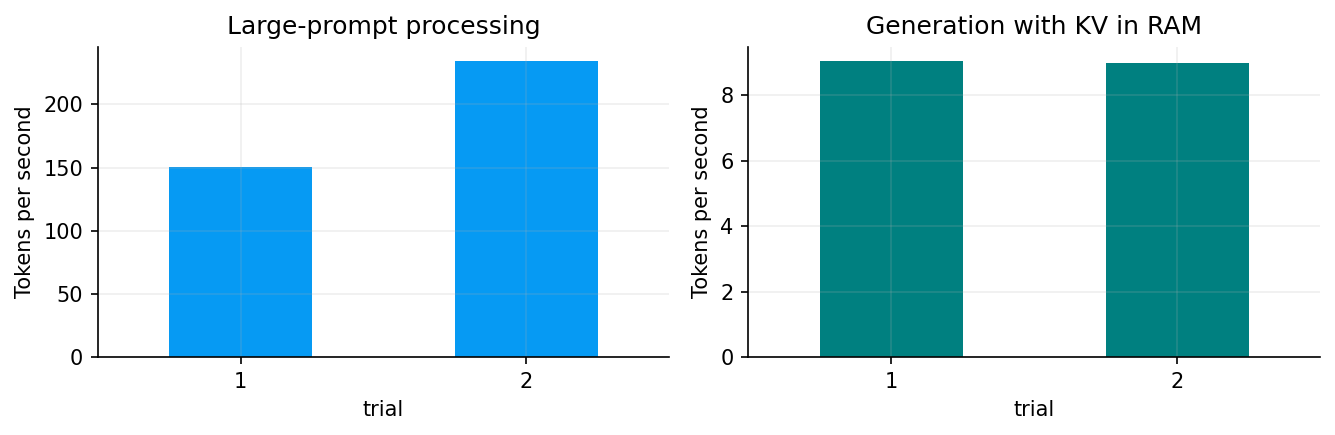

In [5]:
status = runtime_status(runtime)
display(pd.Series(status))
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
trials["prompt_tokens_per_second"].plot.bar(ax=axes[0], color=palette[0], rot=0)
trials["generation_tokens_per_second"].plot.bar(ax=axes[1], color=palette[3], rot=0)
axes[0].set(title="Large-prompt processing", ylabel="Tokens per second")
axes[1].set(title="Generation with KV in RAM", ylabel="Tokens per second")
fig.tight_layout()
plt.show()

,SPY,QQQ,IWM,HYG,LQD,IEF,TLT,GLD,DBC,UUP
date,,,,,,,,,,
2026-09-04,770.19,718.96,296.01,79.16,105.48,92.25,82.21,406.77,31.90,28.08
2026-09-08,765.96,718.36,294.67,79.12,105.48,92.16,82.20,399.72,32.40,27.99
2026-09-09,762.40,716.31,290.64,78.98,105.31,91.90,81.73,403.35,32.85,27.98
2026-09-10,757.83,708.69,287.70,78.62,104.36,91.18,80.78,396.36,33.62,28.03
2026-09-11,764.29,714.88,288.89,78.60,104.32,91.01,80.87,398.77,33.16,28.07


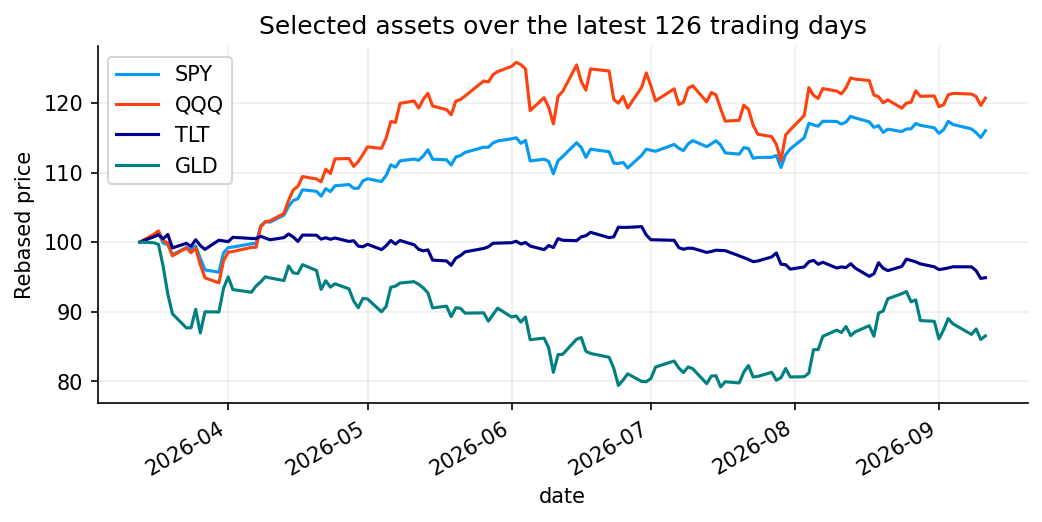

In [6]:
prices = load_yfinance_panel(root / "data/core_cross_asset_etfs.csv", fields=["close"], lowercase=False)["close"]
prices = prices.loc[[close_time(date) <= cutoff for date in prices.index]].tail(800)
assets = [asset for asset in ["SPY", "QQQ", "IWM", "HYG", "LQD", "IEF", "TLT", "GLD", "DBC", "UUP"] if asset in prices]
prices = prices[assets]
returns = prices.pct_change(fill_method=None)
display(prices.tail().round(2))
price_window = prices[["SPY", "QQQ", "TLT", "GLD"]].tail(126)
price_window.div(price_window.iloc[0]).mul(100).plot()
plt.ylabel("Rebased price")
plt.title("Selected assets over the latest 126 trading days")
plt.show()

In [7]:
move_rows = []
for asset in assets:
    values = prices[asset].dropna()
    daily = values.pct_change(fill_method=None)
    history = daily.iloc[-253:-1]
    move_rows.append({"asset": asset, "close": values.iloc[-1],
                      **{f"return_{days}d": values.iloc[-1] / values.iloc[-days-1] - 1 for days in [1, 5, 21, 63]},
                      "move_z": (daily.iloc[-1] - history.mean()) / history.std()})
manual_moves = pd.DataFrame(move_rows).set_index("asset")
display(manual_moves.style.format({"close": "{:.2f}", "move_z": "{:.2f}",
                                   **{f"return_{days}d": "{:.2%}" for days in [1, 5, 21, 63]}}))

,close,return_1d,return_5d,return_21d,return_63d,move_z
asset,,,,,,
SPY,764.29,0.85%,-1.15%,-1.06%,3.86%,0.97
QQQ,714.88,0.87%,-0.39%,-1.22%,-0.20%,0.64
IWM,288.89,0.41%,-2.13%,-4.57%,-0.29%,0.27
HYG,78.60,-0.03%,-0.77%,-1.27%,-1.22%,-0.14
LQD,104.32,-0.04%,-1.12%,-1.70%,-4.03%,-0.08
IEF,91.01,-0.19%,-1.38%,-2.10%,-3.21%,-0.60
TLT,80.87,0.11%,-1.46%,-1.51%,-5.60%,0.23
GLD,398.77,0.61%,-2.79%,-1.52%,3.22%,0.28
DBC,33.16,-1.37%,3.75%,10.13%,14.94%,-1.21


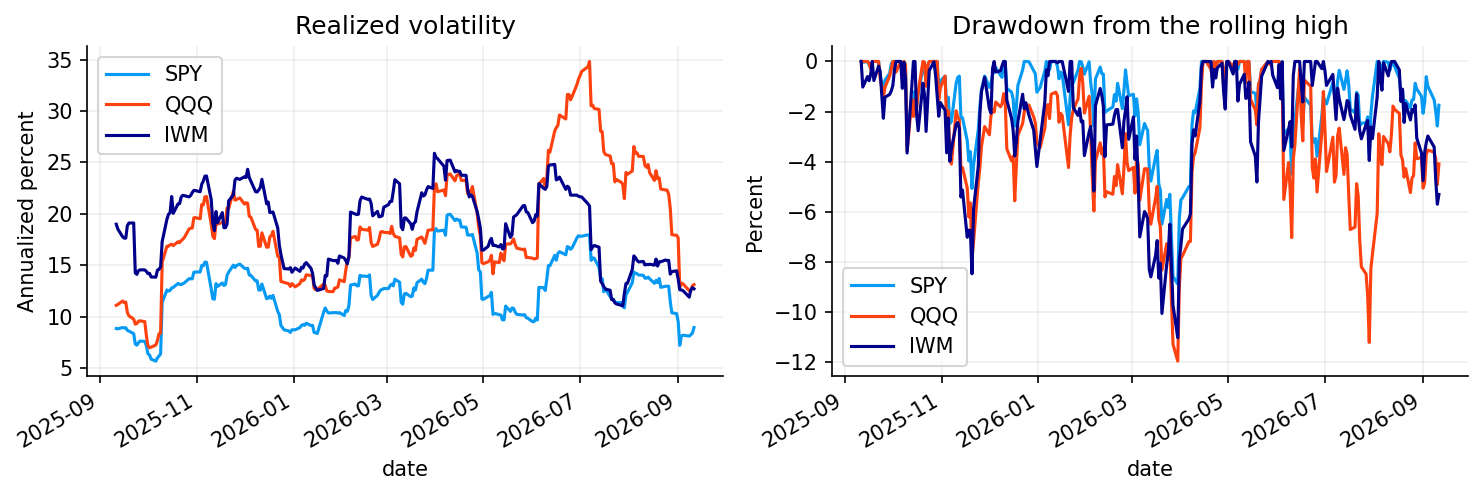

In [8]:
volatility = returns[["SPY", "QQQ", "IWM"]].apply(lambda series: realized_vol(series, 21))
drawdowns = prices[["SPY", "QQQ", "IWM"]].apply(lambda series: drawdown_level(series, 252))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
volatility.tail(252).mul(100).plot(ax=axes[0])
drawdowns.tail(252).mul(100).plot(ax=axes[1])
axes[0].set(title="Realized volatility", ylabel="Annualized percent")
axes[1].set(title="Drawdown from the rolling high", ylabel="Percent")
fig.tight_layout()
plt.show()

,yield_percent,change_1d_bp,change_5d_bp
3M,4.07,7.0,18.0
2Y,4.63,7.0,29.0
5Y,4.78,3.0,26.0
10Y,4.96,1.0,19.0
30Y,5.35,-2.0,10.0


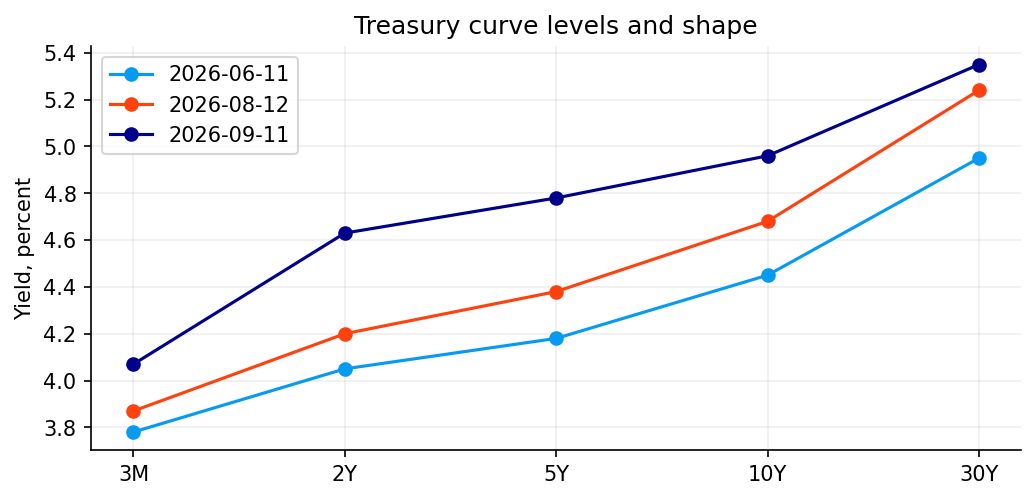

In [9]:
rates = load_par_yield_curve(root / "data/us_treasury_yields.csv", percent=True)
rates = rates.loc[[close_time(date) <= cutoff for date in rates.index]].tail(504)
tenors = ["3M", "2Y", "5Y", "10Y", "30Y"]
rate_changes = rates[tenors].diff().mul(10000)
display(pd.DataFrame({"yield_percent": rates[tenors].iloc[-1] * 100,
                      "change_1d_bp": rate_changes.iloc[-1],
                      "change_5d_bp": (rates[tenors].iloc[-1] - rates[tenors].iloc[-6]) * 10000}).round(2))
fig, ax = plt.subplots()
for position in [-64, -22, -1]:
    ax.plot(tenors, rates[tenors].iloc[position] * 100, marker="o", label=str(rates.index[position].date()))
ax.set(title="Treasury curve levels and shape", ylabel="Yield, percent")
ax.legend()
plt.show()

,daily_gap_pp,gap_z
QQQ minus SPY,0.02,0.00
HYG minus LQD,0.01,-0.03
TLT minus IEF,0.30,0.92
GLD minus SPY,-0.24,-0.15
DBC minus UUP,-1.51,-1.27


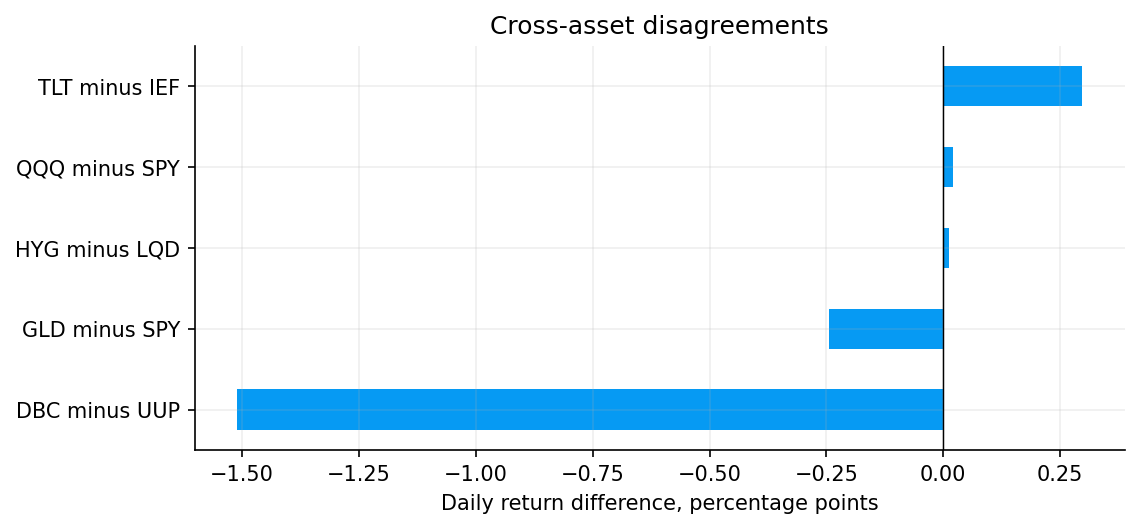

In [10]:
pairs = [("QQQ", "SPY"), ("HYG", "LQD"), ("TLT", "IEF"), ("GLD", "SPY"), ("DBC", "UUP")]
gaps = pd.DataFrame({f"{left} minus {right}": returns[left] - returns[right] for left, right in pairs})
gap_table = pd.DataFrame({"daily_gap_pp": gaps.iloc[-1] * 100,
                          "gap_z": (gaps.iloc[-1] - gaps.iloc[-253:-1].mean()) / gaps.iloc[-253:-1].std()})
display(gap_table.round(2))
gap_table.daily_gap_pp.sort_values().plot.barh(color=palette[0])
plt.axvline(0, color="black", linewidth=0.7)
plt.xlabel("Daily return difference, percentage points")
plt.title("Cross-asset disagreements")
plt.show()

In [11]:
conditions = financial_conditions_context(root, cutoff)
display(pd.Series(conditions.measures))
print("Source notes:", " ".join(conditions.notes))
print("FCI components and NFCI can have different dates; each component retains its own date.")

fci_level                                                                                                                1.233208
fci_percentile                                                                                                           0.813187
stress_breadth                                                                                                           0.416372
policy_pressure                                                                                                          0.327613
inflation_pressure                                                                                                       1.936361
growth_pressure                                                                                                          0.122423
nfci_level                                                                                                                 -0.566
nfci_percentile                                                                           

Source notes: Snapshot of current source revisions. Macro-derived FCI components are stale; their last signal date is 2026-06-30 00:00:00.
FCI components and NFCI can have different dates; each component retains its own date.


In [12]:
cik, entity = resolve_ticker(root, ticker, as_of=cutoff)
filings = local_filings(root, cik)
filings["available_at"] = filings.accepted_at.map(accepted_utc)
filings = filings.loc[filings.available_at.le(cutoff)]
periodic = filings.loc[filings.form_type.isin(["10-Q", "10-K"])].sort_values("available_at")
display(periodic[["form_type", "report_date", "available_at", "accession"]].tail(8))
previous_doc, current_doc = company_filings(root, store, ticker, as_of=cutoff)
display(pd.DataFrame([{"role": label, "period": record.report_period, "available_at": record.available_at,
                      "form": record.form, "url": record.source_url}
                     for label, record in [("prior", previous_doc), ("current", current_doc)]]))

,form_type,report_date,available_at,accession
174,10-Q,2024-10-27,2024-11-20 21:31:22+00:00,0001045810-24-000316
177,10-K,2025-01-26,2025-02-26 21:48:33+00:00,0001045810-25-000023
181,10-Q,2025-04-27,2025-05-28 20:32:57+00:00,0001045810-25-000116
185,10-Q,2025-07-27,2025-08-27 20:52:07+00:00,0001045810-25-000209
187,10-Q,2025-10-26,2025-11-19 21:36:17+00:00,0001045810-25-000230
190,10-K,2026-01-25,2026-02-25 21:42:19+00:00,0001045810-26-000021
195,10-Q,2026-04-26,2026-05-20 20:35:52+00:00,0001045810-26-000052
201,10-Q,2026-07-26,2026-08-26 20:36:00+00:00,0001045810-26-000075


,role,period,available_at,form,url
0,prior,2025-07-27,2025-08-27 20:52:07+00:00,10-Q,https://www.sec.gov/Archives/edgar/data/1045810/000104581025000209/nvda-20250727.htm
1,current,2026-07-26,2026-08-26 20:36:00+00:00,10-Q,https://www.sec.gov/Archives/edgar/data/1045810/000104581026000075/nvda-20260726.htm


In [13]:
facts = read_sec_facts(root / "data/sp500_fundamentals.parquet", ciks=[cik])
facts = facts.merge(filings[["accession", "available_at"]], on="accession", how="inner", validate="many_to_one")
facts = facts.loc[facts.available_at.le(cutoff)].copy()
facts["filed_date"] = pd.to_datetime(facts.available_at, utc=True).dt.tz_localize(None)
display(facts[["concept", "period_end", "value", "unit", "available_at"]].tail(10))
print("Facts without a matching accepted filing are excluded.")

,concept,period_end,value,unit,available_at
23635,us-gaap:WeightedAverageNumberOfSharesOutstandingBasic,2025-07-27,2.440400e+10,shares,2025-08-27 20:52:07+00:00
23636,us-gaap:WeightedAverageNumberOfSharesOutstandingBasic,2025-07-27,2.440400e+10,shares,2026-08-26 20:36:00+00:00
23637,us-gaap:WeightedAverageNumberOfSharesOutstandingBasic,2025-10-26,2.437800e+10,shares,2025-11-19 21:36:17+00:00
23638,us-gaap:WeightedAverageNumberOfSharesOutstandingBasic,2026-01-25,2.435900e+10,shares,2026-02-25 21:42:19+00:00
23639,us-gaap:WeightedAverageNumberOfSharesOutstandingBasic,2025-07-27,2.436600e+10,shares,2025-08-27 20:52:07+00:00
23640,us-gaap:WeightedAverageNumberOfSharesOutstandingBasic,2025-07-27,2.436600e+10,shares,2026-08-26 20:36:00+00:00
23641,us-gaap:WeightedAverageNumberOfSharesOutstandingBasic,2025-10-26,2.432700e+10,shares,2025-11-19 21:36:17+00:00
23642,us-gaap:WeightedAverageNumberOfSharesOutstandingBasic,2026-04-26,2.428600e+10,shares,2026-05-20 20:35:52+00:00
23643,us-gaap:WeightedAverageNumberOfSharesOutstandingBasic,2026-07-26,2.423800e+10,shares,2026-08-26 20:36:00+00:00
23644,us-gaap:WeightedAverageNumberOfSharesOutstandingBasic,2026-07-26,2.419000e+10,shares,2026-08-26 20:36:00+00:00


Facts without a matching accepted filing are excluded.


field,revenue,operating_income,net_income,cfo,free_cash_flow
period_end,,,,,
2024-10-27,35.08,21.87,19.31,17.63,16.81
2025-01-26,39.33,24.03,22.09,16.63,15.55
2025-04-27,44.06,21.64,18.77,27.41,26.19
2025-07-27,46.74,28.44,26.42,15.36,13.47
2025-10-26,57.01,36.01,31.91,NaN,NaN
2026-01-25,68.13,44.30,42.96,36.19,34.90
2026-04-26,81.61,53.54,58.32,50.34,48.59
2026-07-26,96.22,63.73,59.69,24.08,21.40


Missing quarter values remain missing; absent cash-flow bars represent gaps in the reconstructed series.


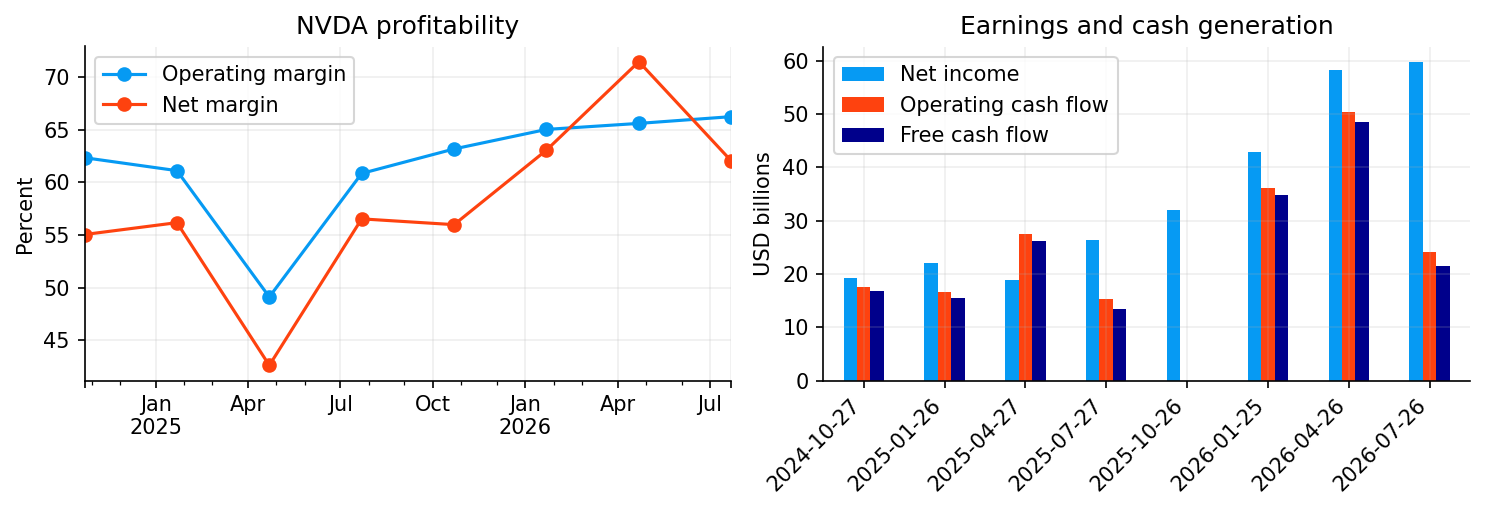

In [14]:
classified = classify_duration_facts(facts)
selected_facts = select_filing_facts(classified)
quarters, reconstruction_checks = reconstruct_quarters(selected_facts)
quarterly = quarters.sort_values("filed_date").drop_duplicates(["field", "period_end"], keep="last")
quarterly = quarterly.pivot(index="period_end", columns="field", values="value").sort_index().tail(8)
margins = pd.DataFrame({"operating_margin": operating_margin(quarterly.operating_income, quarterly.revenue),
                        "net_margin": net_margin(quarterly.net_income, quarterly.revenue)})
quarterly["free_cash_flow"] = free_cash_flow(quarterly.cfo, quarterly.capex)
display(quarterly[["revenue", "operating_income", "net_income", "cfo", "free_cash_flow"]].div(1e9).round(2))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
margins.rename(columns={"operating_margin": "Operating margin", "net_margin": "Net margin"}).mul(100).plot(ax=axes[0], marker="o")
cash_flows = quarterly[["net_income", "cfo", "free_cash_flow"]].div(1e9)
cash_flows = cash_flows.rename(index=lambda date: str(date.date()),
                              columns={"net_income": "Net income", "cfo": "Operating cash flow", "free_cash_flow": "Free cash flow"})
cash_flows.plot.bar(ax=axes[1])
axes[0].set(title=f"{ticker} profitability", ylabel="Percent")
axes[1].set(title="Earnings and cash generation", ylabel="USD billions")
axes[1].set_xticklabels([str(date.date()) for date in quarterly.index], rotation=45, ha="right")
axes[1].legend(title=None)
for ax in axes:
    ax.set_xlabel("")
print("Missing quarter values remain missing; absent cash-flow bars represent gaps in the reconstructed series.")
fig.tight_layout()
plt.show()

,documents,first_available,latest_available,characters
source,,,,
bea,28,2020-02-28 13:30:00+00:00,2026-08-26 12:30:00+00:00,240900
bls,510,2016-01-08 13:30:00+00:00,2026-09-12 20:30:50.860242+00:00,62580695
cftc,1,2026-09-12 20:25:05.398215+00:00,2026-09-12 20:25:05.398215+00:00,24585
eia,8,2026-09-12 20:24:59.136282+00:00,2026-09-12 20:25:04.728959+00:00,57824
fed,194,2016-01-27 19:00:00+00:00,2026-09-03 12:30:00+00:00,5278736
gdelt,23,2026-09-12 21:35:24.194694+00:00,2026-09-14 16:05:44.294802+00:00,5619
sec,411,2012-01-19 21:05:03+00:00,2026-09-03 12:03:56+00:00,59037399


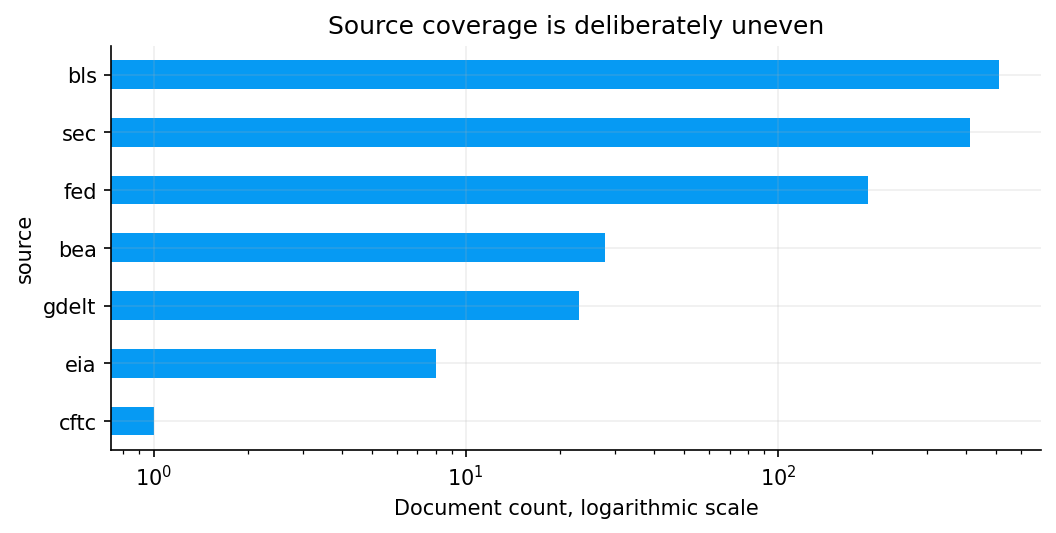

In [15]:
coverage = document_coverage(store.records(as_of=cutoff))
source_coverage = coverage.groupby("source").agg(documents=("document_id", "nunique"),
    first_available=("available_at", "min"), latest_available=("available_at", "max"), characters=("characters", "sum"))
display(source_coverage)
source_coverage.documents.sort_values().plot.barh(logx=True)
plt.xlabel("Document count, logarithmic scale")
plt.title("Source coverage is deliberately uneven")
plt.show()

,section,words
0,Document,2154
1,Item 1. Financial Statements (Unaudited),2926
2,Notes to Condensed Consolidated Financial Statements,1
3,Note 1 - Summary of Significant Accounting Policies,484
4,Note 2 - Stock-Based Compensation,36
5,Notes to Condensed Consolidated Financial Statements (Continued),280
6,Note 3 - Net Income Per Share,287
7,Notes to Condensed Consolidated Financial Statements (Continued),1


,chunk_id,section,estimated_tokens,text
0,sec-85e63b2d64645bc01bbe1f8d:0:2a83be11ca,Document,798,NVIDIA CORP 10-Q 2026-07-26 00:00:00 | NVDA | 10-Q | 2026-07-26 | Document\n\nxbrli:shares iso42...
1,sec-85e63b2d64645bc01bbe1f8d:1:70f415ab1f,Document,797,NVIDIA CORP 10-Q 2026-07-26 00:00:00 | NVDA | 10-Q | 2026-07-26 | Document\n\n2026-01-26 2026-07...
2,sec-85e63b2d64645bc01bbe1f8d:2:d8ace2d251,Document,797,NVIDIA CORP 10-Q 2026-07-26 00:00:00 | NVDA | 10-Q | 2026-07-26 | Document\n\nus-gaap:EquitySecu...
3,sec-85e63b2d64645bc01bbe1f8d:3:a639a7fd01,Document,790,NVIDIA CORP 10-Q 2026-07-26 00:00:00 | NVDA | 10-Q | 2026-07-26 | Document\n\n0001045810 nvda:Pu...
4,sec-85e63b2d64645bc01bbe1f8d:4:5926707c02,Document,790,NVIDIA CORP 10-Q 2026-07-26 00:00:00 | NVDA | 10-Q | 2026-07-26 | Document\n\nus-gaap:USGovernme...
5,sec-85e63b2d64645bc01bbe1f8d:5:a22d43a9a1,Document,798,NVIDIA CORP 10-Q 2026-07-26 00:00:00 | NVDA | 10-Q | 2026-07-26 | Document\n\nus-gaap:FairValueI...
6,sec-85e63b2d64645bc01bbe1f8d:6:aa805eed0c,Document,797,NVIDIA CORP 10-Q 2026-07-26 00:00:00 | NVDA | 10-Q | 2026-07-26 | Document\n\n0001045810 nvda:In...
7,sec-85e63b2d64645bc01bbe1f8d:7:a490eae0dc,Document,798,NVIDIA CORP 10-Q 2026-07-26 00:00:00 | NVDA | 10-Q | 2026-07-26 | Document\n\nus-gaap:NotesPayab...


,section,estimated_tokens,model_tokens
0,Document,798,1493
10,Document,800,1193
21,Item 1. Financial Statements (Unaudited),118,143
31,Note 4 - Intangible Assets and Goodwill,502,597
42,Note 8 - Derivative Financial Instruments,661,429
52,Notes to Condensed Consolidated Financial Statements (Continued),408,416
63,Notes to Condensed Consolidated Financial Statements (Continued),283,237
73,Item 2. Management’s Discussion and Analysis of Financial Condition and Results of Operations,557,357
84,Item 2. Management’s Discussion and Analysis of Financial Condition and Results of Operations,108,103
94,Item 1A. Risk Factors,127,111


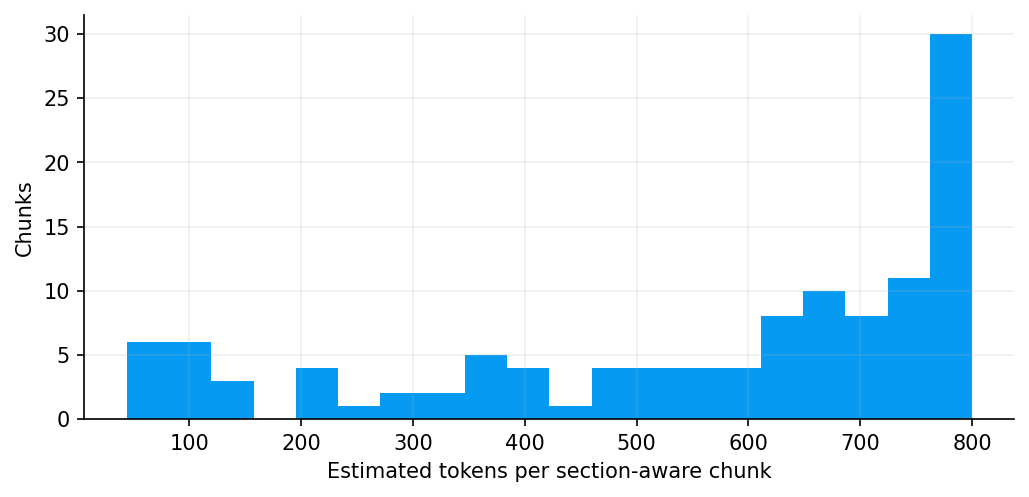

In [16]:
filing_sections = sections(current_doc.text)
display(pd.DataFrame([{"section": name, "words": len(text.split())} for name, text in filing_sections]).head(8))
chunks = chunk_document(current_doc)
chunk_table = pd.DataFrame([{"chunk_id": row.chunk_id, "section": row.section, "estimated_tokens": row.token_count,
                            "text": row.text[:320]} for row in chunks])
display(chunk_table.head(8))
token_sample = chunk_table.iloc[np.linspace(0, len(chunks) - 1, min(12, len(chunks)), dtype=int)].copy()
token_sample["model_tokens"] = [runtime.count(chunks[position].text)
                                for position in np.linspace(0, len(chunks) - 1, len(token_sample), dtype=int)]
display(token_sample[["section", "estimated_tokens", "model_tokens"]])
chunk_table.estimated_tokens.hist(bins=20, color=palette[0])
plt.xlabel("Estimated tokens per section-aware chunk")
plt.ylabel("Chunks")
plt.show()

In [17]:
index = DocumentIndex(config.workspace / "index/documents.sqlite")
new_chunks = index_new_documents(index, store.records(as_of=cutoff))
queries = ["liquidity cash debt", "operating margin revenue", "customer concentration risk"]
searches = [index.search(query, as_of=cutoff, sources=["sec"], ticker=ticker,
                         since=cutoff - timedelta(days=90), limit=15) for query in queries]
search_rows = [{"query": query, "rank": rank, "chunk_id": chunk.chunk_id, "section": chunk.section,
                "bm25": score, "available_at": chunk.available_at, "excerpt": chunk.text[:240]}
               for query, results in zip(queries, searches) for rank, (chunk, score) in enumerate(results, 1)]
search_table = pd.DataFrame(search_rows)
display(search_table.head(10))
print("New chunks indexed:", new_chunks, "| BM25 uses lower scores for better lexical matches.")

,query,rank,chunk_id,section,bm25,available_at,excerpt
0,liquidity cash debt,1,sec-85e63b2d64645bc01bbe1f8d:85:c2b0914681,Liquidity and Capital Resources,-20.020696,2026-08-26 20:36:00+00:00,NVIDIA CORP 10-Q 2026-07-26 00:00:00 | NVDA | 10-Q | 2026-07-26 | Liquidity and Capital Resource...
1,liquidity cash debt,2,sec-85e63b2d64645bc01bbe1f8d:86:29debd12b0,Liquidity and Capital Resources,-17.254216,2026-08-26 20:36:00+00:00,NVIDIA CORP 10-Q 2026-07-26 00:00:00 | NVDA | 10-Q | 2026-07-26 | Liquidity and Capital Resource...
2,liquidity cash debt,3,sec-85e63b2d64645bc01bbe1f8d:87:63795e96ca,Liquidity and Capital Resources,-16.615834,2026-08-26 20:36:00+00:00,NVIDIA CORP 10-Q 2026-07-26 00:00:00 | NVDA | 10-Q | 2026-07-26 | Liquidity and Capital Resource...
3,liquidity cash debt,4,sec-85e63b2d64645bc01bbe1f8d:111:c822af6487,Item 1A. Risk Factors,-13.969220,2026-08-26 20:36:00+00:00,NVIDIA CORP 10-Q 2026-07-26 00:00:00 | NVDA | 10-Q | 2026-07-26 | Item 1A. Risk Factors\n\nFinal...
4,liquidity cash debt,5,sec-85e63b2d64645bc01bbe1f8d:22:5b95c67690,Item 1. Financial Statements (Unaudited),-13.672133,2026-08-26 20:36:00+00:00,NVIDIA CORP 10-Q 2026-07-26 00:00:00 | NVDA | 10-Q | 2026-07-26 | Item 1. Financial Statements (...
5,liquidity cash debt,6,sec-85e63b2d64645bc01bbe1f8d:32:2b8626b9e4,Notes to Condensed Consolidated Financial Statements (Continued),-13.666135,2026-08-26 20:36:00+00:00,NVIDIA CORP 10-Q 2026-07-26 00:00:00 | NVDA | 10-Q | 2026-07-26 | Notes to Condensed Consolidate...
6,liquidity cash debt,7,sec-85e63b2d64645bc01bbe1f8d:34:545d4f3a2f,Notes to Condensed Consolidated Financial Statements (Continued),-13.264511,2026-08-26 20:36:00+00:00,NVIDIA CORP 10-Q 2026-07-26 00:00:00 | NVDA | 10-Q | 2026-07-26 | Notes to Condensed Consolidate...
7,liquidity cash debt,8,sec-ab8c2344bed76f76304cc502:11:fe8ff7fb78,Document,-13.208521,2026-08-26 20:21:19+00:00,NVIDIA CORP EX-99.1 2026-08-26 00:00:00 | NVDA | EX-99.1 | 2026-08-26 | Document\n\nCash flows f...
8,liquidity cash debt,9,sec-ab8c2344bed76f76304cc502:9:419cf35231,Document,-13.201854,2026-08-26 20:21:19+00:00,NVIDIA CORP EX-99.1 2026-08-26 00:00:00 | NVDA | EX-99.1 | 2026-08-26 | Document\n\nNVIDIA CORPO...
9,liquidity cash debt,10,sec-ab8c2344bed76f76304cc502:10:a3177da832,Document,-13.038790,2026-08-26 20:21:19+00:00,NVIDIA CORP EX-99.1 2026-08-26 00:00:00 | NVDA | EX-99.1 | 2026-08-26 | Document\n\nNVIDIA CORPO...


New chunks indexed: 0 | BM25 uses lower scores for better lexical matches.


In [18]:
retrieval_question = f"What changed in {ticker}'s liquidity, operating margins and customer concentration?"
deterministic_plan = query_plan(retrieval_question, tickers=[ticker])
display(pd.Series(deterministic_plan))
model_plan = resolve_plan(config, runtime, retrieval_question, as_of=cutoff, ticker=ticker, use_model=True)
display(pd.Series(model_plan.model_dump()))
print("Model planning is optional; invalid plans fall back to the visible rule-based route.")

entities                                                                                                     [NVDA]
sources                                                                                                       [sec]
contexts                                                                      [credit, factors, fundamentals, risk]
queries                [What changed in NVDA's liquidity, operating margins and customer concentration?, liquidity]
requires_model_plan                                                                                           False
dtype: object

entities                                                                                               [NVDA]
sources                                                                                                 [sec]
contexts                                                                [fundamentals, risk, credit, factors]
queries          [What changed in NVDA's liquidity, operating margins and customer concentration?, liquidity]
sections                                                                                                   []
lookback_days                                                                                              90
dtype: object

Model planning is optional; invalid plans fall back to the visible rule-based route.


,reciprocal_rank_score
chunk_id,
sec-85e63b2d64645bc01bbe1f8d:79:c1d78047e7,0.030090
sec-85e63b2d64645bc01bbe1f8d:64:f7f3b1eea4,0.028370
sec-85e63b2d64645bc01bbe1f8d:104:8282557a4d,0.016393
sec-85e63b2d64645bc01bbe1f8d:85:c2b0914681,0.016393
sec-ab8c2344bed76f76304cc502:14:482afc97a7,0.016393
sec-ab8c2344bed76f76304cc502:12:884b157309,0.016129
sec-85e63b2d64645bc01bbe1f8d:86:29debd12b0,0.016129
sec-85e63b2d64645bc01bbe1f8d:109:0042f7be51,0.016129
sec-85e63b2d64645bc01bbe1f8d:81:6dd03d2510,0.015873


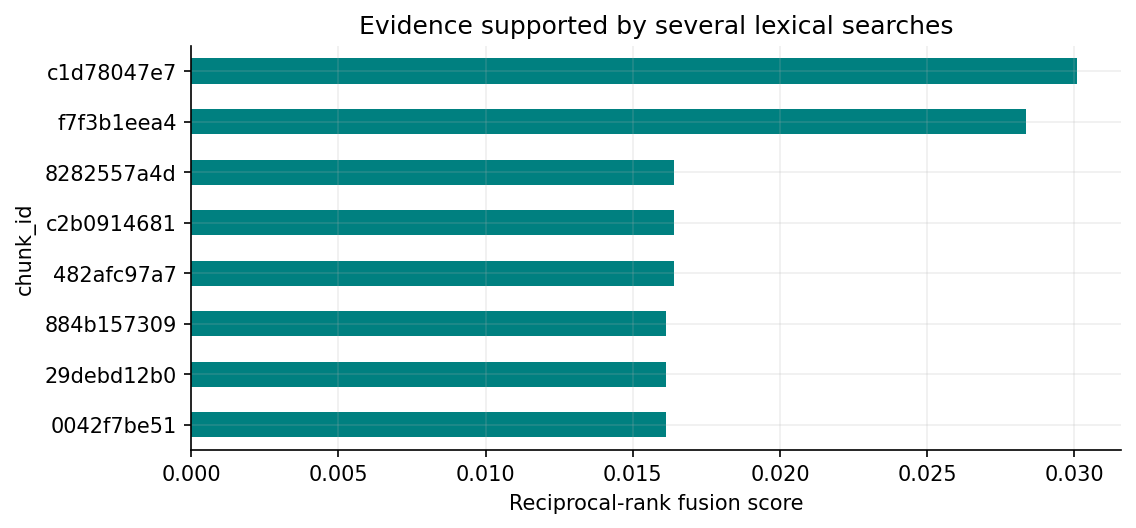

In [19]:
search_table["reciprocal_rank"] = 1 / (60 + search_table["rank"])
fusion_scores = search_table.groupby("chunk_id").reciprocal_rank.sum().sort_values(ascending=False)
fused = fuse_results(searches)
display(fusion_scores.head(10).rename("reciprocal_rank_score").to_frame())
fusion_scores.head(8).iloc[::-1].plot.barh(color=palette[3])
plt.yticks(range(min(8, len(fusion_scores))), [key.split(":")[-1] for key in fusion_scores.head(8).iloc[::-1].index])
plt.xlabel("Reciprocal-rank fusion score")
plt.title("Evidence supported by several lexical searches")
plt.show()

In [20]:
selected_rows, seen = [], set()
document_budget = 8000
for chunk, score in fused:
    if chunk.text_hash in seen:
        continue
    passage = chunk.text.partition("\n\n")[2] or chunk.text
    row = evidence_row(passage, key=chunk.chunk_id, document_id=chunk.document_id,
                       available_at=chunk.available_at, source=chunk.source, title=chunk.title,
                       tickers=chunk.tickers, entities=chunk.entities)
    tokens = runtime.count(json.dumps({"as_of": cutoff.isoformat(), "evidence": [*selected_rows, row]}))
    if tokens <= document_budget:
        selected_rows.append(row)
        seen.add(chunk.text_hash)
selected_rows = attach_sources(selected_rows, store)
display(pd.DataFrame(selected_rows)[["evidence_id", "title", "available_at"]])
print("Selected documents are available before the cutoff and fit the evidence budget.")

,evidence_id,title,available_at
0,sec-85e63b2d64645bc01bbe1f8d:79:c1d78047e7,NVIDIA CORP 10-Q 2026-07-26 00:00:00,2026-08-26T20:36:00+00:00
1,sec-85e63b2d64645bc01bbe1f8d:64:f7f3b1eea4,NVIDIA CORP 10-Q 2026-07-26 00:00:00,2026-08-26T20:36:00+00:00
2,sec-85e63b2d64645bc01bbe1f8d:104:8282557a4d,NVIDIA CORP 10-Q 2026-07-26 00:00:00,2026-08-26T20:36:00+00:00
3,sec-85e63b2d64645bc01bbe1f8d:85:c2b0914681,NVIDIA CORP 10-Q 2026-07-26 00:00:00,2026-08-26T20:36:00+00:00
4,sec-ab8c2344bed76f76304cc502:14:482afc97a7,NVIDIA CORP EX-99.1 2026-08-26 00:00:00,2026-08-26T20:21:19+00:00
5,sec-85e63b2d64645bc01bbe1f8d:109:0042f7be51,NVIDIA CORP 10-Q 2026-07-26 00:00:00,2026-08-26T20:36:00+00:00
6,sec-85e63b2d64645bc01bbe1f8d:86:29debd12b0,NVIDIA CORP 10-Q 2026-07-26 00:00:00,2026-08-26T20:36:00+00:00
7,sec-ab8c2344bed76f76304cc502:12:884b157309,NVIDIA CORP EX-99.1 2026-08-26 00:00:00,2026-08-26T20:21:19+00:00
8,sec-85e63b2d64645bc01bbe1f8d:106:e98428652a,NVIDIA CORP 10-Q 2026-07-26 00:00:00,2026-08-26T20:36:00+00:00


Selected documents are available before the cutoff and fit the evidence budget.


In [21]:
candidates = candidate_events(store.records(as_of=cutoff), as_of=cutoff, days=30)
display(pd.DataFrame(candidates[:10])[["source", "family", "content_date", "available_at", "title"]])
event_document = store.get(candidates[0]["document_id"])
event_question = f"What happened in this {candidates[0]['family']} event, what changed and why does it matter?"
event_plan = QueryPlan(entities=event_document.tickers, sources=[event_document.source], contexts=[], queries=[event_document.title], lookback_days=14)
event_matches = retrieve_queries(index, event_plan.queries, as_of=cutoff, sources=event_plan.sources,
                                 since=cutoff - timedelta(days=event_plan.lookback_days))
event_matches = [row for row in event_matches if row[0].document_id != event_document.document_id]
event_search = pack_evidence(event_matches, as_of=cutoff, budget=config.evidence_tokens, count=runtime.count,
                             max_per_document=1, max_items=2)
event_rows = merge_evidence(event_evidence(event_document), attach_sources(event_search["evidence"], store), as_of=cutoff)
event_packet, event_budget = fit_evidence(event_question, event_rows, as_of=cutoff, task="event",
    entities=event_plan.entities, context_status=[], runtime=runtime, config=config)
display(pd.DataFrame(event_packet["evidence"])[["source", "title", "available_at"]])

,source,family,content_date,available_at,title
0,eia,energy,2026-09-10,2026-09-12T20:25:04.728959+00:00,Weekly Petroleum Status Report highlights
1,bls,inflation,2026-09-10,2026-09-10T12:30:00+00:00,Producer Price Index News Release
2,cftc,positioning,2026-09-08,2026-09-12T20:25:05.398215+00:00,CFTC NYMEX futures positioning
3,bls,labor,2026-09-04,2026-09-04T12:30:00+00:00,Employment Situation News Release
4,fed,monetary_policy,2026-09-03,2026-09-03T12:30:00+00:00,"Waller, The Economic Outlook and Some Comments on My Policy Communication"
5,sec,other_material,2026-09-03,2026-09-03T12:03:56+00:00,NVIDIA CORP 8-K 2026-09-02 00:00:00
6,eia,energy,2026-09-02,2026-09-12T20:25:03.973622+00:00,Weekly Petroleum Status Report highlights
7,bls,labor,2026-09-01,2026-09-01T14:00:00+00:00,Job Openings and Labor Turnover Survey News Release
8,fed,monetary_policy,2026-09-01,2026-09-01T13:05:00+00:00,"Barr, Unlocking Opportunities for Workers and Entrepreneurs with a Criminal Record"
9,sec,corporate_results,2026-08-28,2026-08-28T20:11:28+00:00,Walmart Inc. 10-Q 2026-07-31 00:00:00


,source,title,available_at
0,eia,Weekly Petroleum Status Report highlights,2026-09-12T20:25:04.728959+00:00
1,eia,Weekly Petroleum Status Report highlights,2026-09-12T20:25:04.728959+00:00
2,eia,Weekly Petroleum Status Report highlights,2026-09-12T20:25:04.728959+00:00
3,eia,Weekly Petroleum Status Report highlights,2026-09-12T20:25:04.728959+00:00
4,eia,Weekly Petroleum Status Report highlights,2026-09-12T20:25:04.728959+00:00
5,eia,Weekly Petroleum Status Report highlights,2026-09-12T20:25:04.728959+00:00
6,eia,Weekly Petroleum Status Report highlights,2026-09-12T20:25:03.973622+00:00


,tokens
packed prompt,3344
answer,2300
repair and safety reserve,3836
unused capacity,15096


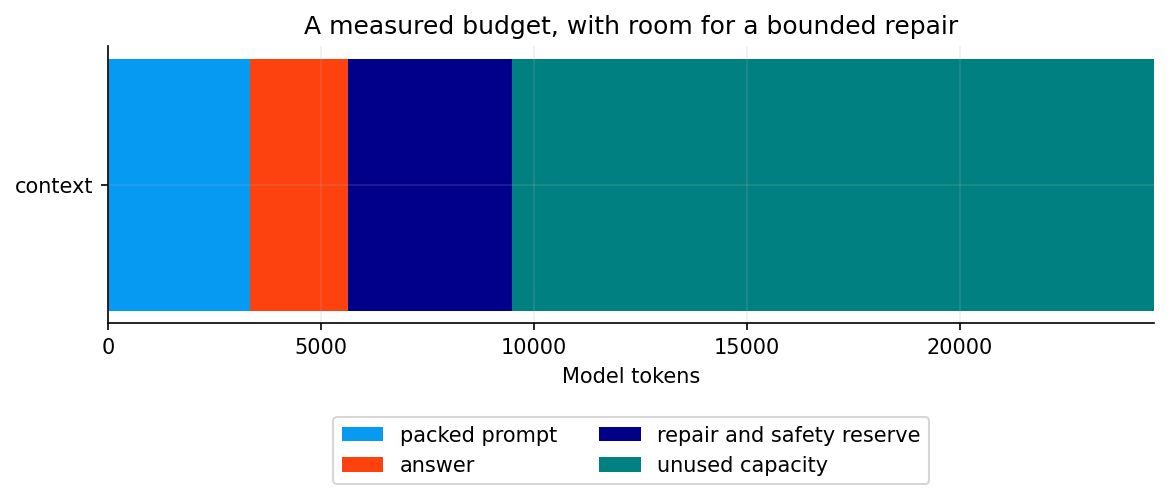

In [22]:
budget_parts = pd.Series({"packed prompt": event_budget["prompt_tokens"], "answer": config.generation_tokens,
                          "repair and safety reserve": config.generation_tokens + 1536,
                          "unused capacity": config.context_tokens - event_budget["prompt_tokens"] - 2 * config.generation_tokens - 1536})
display(budget_parts.to_frame("tokens"))
fig, ax = plt.subplots(figsize=(9, 2.4))
left = 0
for color, (label, tokens) in zip(palette, budget_parts.items()):
    ax.barh("context", tokens, left=left, label=label, color=color)
    left += tokens
ax.set(xlim=(0, config.context_tokens), xlabel="Model tokens", title="A measured budget, with room for a bounded repair")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=2)
plt.show()

In [23]:
event_key = response_key(published["sha256"], config.prompt_version, event_question, event_packet,
                         task="event", generation_tokens=config.generation_tokens)
event_cache = config.workspace / "responses" / f"{event_key}.json"
event_report = load_response(event_cache)
event_messages = analysis_messages(event_question, event_packet)
if event_report is None:
    generated = runtime.generate(event_messages, schema=response_schema(event_packet))
    event_target, event_errors = check_response(generated["text"], event_packet,
                                               stopped=generated["stopped"] and not generated["truncated"])
    event_attempts = [{**generated, "errors": event_errors}]
    save_json(config.workspace / "last_generation.json", {"output": generated, "errors": event_errors})
else:
    event_target, event_errors, event_attempts = event_report.analysis, event_report.errors, event_report.attempts
    print("Saved event answer reused; no generation repeated.")
display(pd.DataFrame([{"attempt": i + 1, "seconds": row["seconds"], "errors": "; ".join(row["errors"])}
                      for i, row in enumerate(event_attempts)]))

Saved event answer reused; no generation repeated.


,attempt,seconds,errors
0,1,34.0,


In [24]:
if event_report is None:
    if event_errors:
        repaired = runtime.generate(repair_messages(event_messages, generated["text"], event_errors),
                                    schema=response_schema(event_packet))
        event_target, event_errors = check_response(repaired["text"], event_packet,
                                                   stopped=repaired["stopped"] and not repaired["truncated"])
        event_attempts.append({**repaired, "errors": event_errors})
    if event_errors:
        event_target = supported_subset(event_target, event_packet)
    event_report = AnalysisReport(event_question, "event", cutoff.isoformat(), event_target, event_packet,
                                  event_errors, event_attempts, event_key)
    save_json(event_cache, event_report.to_dict())
if event_report.analysis is not None:
    claim_audit = [{"kind": claim.kind, "claim": claim.statement, "citations": len(claim.evidence_ids),
                    "number_tokens": ", ".join(sorted(financial_numbers(claim.statement)))}
                   for claim in event_report.analysis.claims]
    display(pd.DataFrame(claim_audit))
print("Validation issues:", event_report.errors)

,kind,claim,citations,number_tokens
0,fact,"For the week ending September 04, 2026, U.S. refineries processed 17.6 million barrels per day (...",1,"1.76E+7:number, 2026:number, 4:number, 9.1E+4:number, 97.8:percent"
1,interpretation,"The reported demand increase raises concern about capacity availability, while the price increas...",3,


Validation issues: []


In [25]:
event_store = EventStore(config.workspace / "events/events.sqlite")
event_record = event_from_report(event_report, event_document, model_sha=published["sha256"], prompt_version=config.prompt_version)
if event_record is not None:
    event_store.put(event_record)
print(event_question)
display(event_report)

What happened in this energy event, what changed and why does it matter?


AnalysisReport(question='What happened in this energy event, what changed and why does it matter?', task='event', as_of='2026-09-14T16:57:55+00:00', analysis=AnalysisTarget(conclusion='For the week ending September 04, 2026, U.S. refineries processed 17.6 million barrels per day (b/d)—up 91,000 b/d from the previous week—at 97.8% capacity utilization. The reported demand increase raises concern about capacity availability, while the price increase and higher gasoline prices indicate a positive demand response.', materiality='high', claims=[Claim(statement='For the week ending September 04, 2026, U.S. refineries processed 17.6 million barrels per day (b/d)—up 91,000 b/d from the previous week—at 97.8% capacity utilization.', evidence_ids=['eia-08503df8dc8ac80de4cd9615:narrative:0'], kind='fact'), Claim(statement='The reported demand increase raises concern about capacity availability, while the price increase and higher gasoline prices indicate a positive demand response.', evidence_ids=['eia-08503df8dc8ac80de4cd9615:narrative:0', 'eia-08503df8dc8ac80de4cd9615:narrative:1', 'eia-08503df8dc8ac80de4cd9615:narrative:2'], kind='interpretation')], what_changed='For the week ending September 04, 2026, U.S. refineries processed 17.6 million barrels per day (b/d)—up 91,000 b/d from the previous week—at 97.8% capacity utilization. The reported demand increase raises concern about capacity availability, while the price increase and higher gasoline prices indicate a positive demand response.', why_it_matters='The reported demand increase raises concern about capacity availability, while the price increase and higher gasoline prices indicate a positive demand response.', uncertainty=['The passage alone does not establish the sole driver of any asset-price move.', 'The comparison covers a specified time window, but a recent release does not establish a causal market reaction.']), packet={'as_of': '2026-09-14T16:57:55+00:00', 'task': 'event', 'entities': [], 'evidence': [{'evidence_id': 'eia-08503df8dc8ac80de4cd9615:narrative:0', 'document_id': 'eia-08503df8dc8ac80de4cd9615', 'available_at': '2026-09-12T20:25:04.728959+00:00', 'source': 'eia', 'title': 'Weekly Petroleum Status Report highlights', 'tickers': [], 'entities': [], 'text': 'For the week ending September 04, 2026, U.S. refineries processed 17.6 million barrels per day (b/d)—up 91,000 b/d from the previous week—at 97.8% capacity utilization. Gasoline output averaged 9.3 million b/d, and distillate production increased to 5.3 million b/d.', 'text_hash': '7024272f136cca445a72f49cbba3cd9513a29063c0cba51e93a13f978a54defe', 'source_url': 'https://www.eia.gov/petroleum/supply/weekly/archive/2026/2026_09_10/pdf/highlights.pdf'}, {'evidence_id': 'eia-08503df8dc8ac80de4cd9615:narrative:1', 'document_id': 'eia-08503df8dc8ac80de4cd9615', 'available_at': '2026-09-12T20:25:04.728959+00:00', 'source': 'eia', 'title': 'Weekly Petroleum Status Report highlights', 'tickers': [], 'entities': [], 'text': 'Crude oil imports increased 53,000 b/d to 6.8 million b/d, and the four-week average of 6.6 million b/d is 2.3% above the year-ago level. Gasoline imports averaged 464,000 b/d; distillate imports averaged 185,000 b/d.', 'text_hash': 'd84da0d4ed781c45bdc67f613a84cad17b4b0fab20440b94c9ba48619536f714', 'source_url': 'https://www.eia.gov/petroleum/supply/weekly/archive/2026/2026_09_10/pdf/highlights.pdf'}, {'evidence_id': 'eia-08503df8dc8ac80de4cd9615:narrative:2', 'document_id': 'eia-08503df8dc8ac80de4cd9615', 'available_at': '2026-09-12T20:25:04.728959+00:00', 'source': 'eia', 'title': 'Weekly Petroleum Status Report highlights', 'tickers': [], 'entities': [], 'text': 'Commercial crude oil inventories (excluding the Strategic Petroleum Reserve) decreased 0.4 million barrels to 424.1 million barrels, matching the five-year average. Gasoline inventories increased 1.3 million barrels, 5% below the five-year average. Distillate inventories increased 2.1 million barrels, 13% below the five-year average. Pr

In [26]:
library_moves = market_moves(prices)
library_risk = risk_measures(prices)
library_curve = curve_moves(rates)
library_shape = curve_shape(rates)
library_gaps = relative_moves(prices)
agreement = (library_moves[manual_moves.columns] - manual_moves).abs().max().rename("maximum_absolute_difference")
display(agreement.to_frame())
display(library_risk.round(4))
display(library_curve.round(2))
display(library_gaps.round(2))
assert np.allclose(agreement, 0, atol=1e-10)

,maximum_absolute_difference
close,0.0
return_1d,0.0
return_5d,0.0
return_21d,0.0
return_63d,0.0
move_z,0.0


,realized_vol_21d,drawdown_252d,beta_spy_63d,correlation_spy_63d
asset,,,,
SPY,0.0894,-0.0175,1.0000,1.0000
QQQ,0.1312,-0.0409,1.6616,0.9041
IWM,0.1271,-0.0531,0.8298,0.7348
HYG,0.0362,-0.0159,0.1910,0.7012
LQD,0.0650,-0.0486,0.2083,0.4699
IEF,0.0527,-0.0561,0.1604,0.4016
TLT,0.1109,-0.0928,0.2346,0.2995
GLD,0.2765,-0.1959,0.7354,0.3591
DBC,0.1843,-0.0137,-0.6029,-0.3319


,yield_percent,change_1d_bp,change_5d_bp,move_z
tenor,,,,
3M,4.07,7.0,18.0,3.23
2Y,4.63,7.0,29.0,1.47
5Y,4.78,3.0,26.0,0.56
10Y,4.96,1.0,19.0,0.16
30Y,5.35,-2.0,10.0,-0.63


,return_gap_1d_pp,return_gap_5d_pp,gap_z,correlation_63d
pair,,,,
QQQ_minus_SPY,0.02,0.76,0.00,0.90
HYG_minus_LQD,0.01,0.35,-0.03,0.79
TLT_minus_IEF,0.30,-0.09,0.92,0.89
GLD_minus_SPY,-0.24,-1.64,-0.15,0.36
DBC_minus_UUP,-1.51,3.54,-1.27,-0.10


In [27]:
registry = ContextRegistry(root)
context_names = ["market", "risk", "volatility", "rates", "financial_conditions", "factors",
                 "cross_asset", "fundamentals", "credit", "macro"]
snapshots = {name: registry.build(name, as_of=cutoff, ticker=ticker) for name in context_names}
display(pd.DataFrame([{"context": name, "public_builder": registry.builders[name].__name__, "freshness": snapshot.freshness,
                      "latest_data_at": snapshot.latest_data_at, "notes": " ".join(snapshot.notes)}
                     for name, snapshot in snapshots.items()]))
context_rows, context_status = context_evidence(list(snapshots.values()), count=runtime.count, ticker=ticker)
display(pd.DataFrame(context_rows)[["evidence_id", "title", "available_at"]])

,context,public_builder,freshness,latest_data_at,notes
0,market,market_context,current,2026-09-11 22:00:00+00:00,Returns use the existing adjusted-price panel; prices are not a vendor-vintage archive. Daily ob...
1,risk,risk_context,current,2026-09-11 22:00:00+00:00,
2,volatility,volatility_context,current,2026-09-11 22:00:00+00:00,Options-based variance risk premium and heavy forecasts require a separately refreshed snapshot....
3,rates,rates_context,current,2026-09-11 22:00:00+00:00,Curve measures use Treasury par yields; curvature is the 2x5Y-2Y-10Y butterfly in basis points. ...
4,financial_conditions,financial_conditions_context,current,2026-08-31 22:00:00+00:00,Snapshot of current source revisions. Macro-derived FCI components are stale; their last signal ...
5,factors,factors_context,stale,2026-06-17 22:00:00+00:00,"Tradable daily factor-proxy spreads from Project 15, not academic factor realizations."
6,cross_asset,cross_asset_context,current,2026-09-11 22:00:00+00:00,"Breadth refers to the selected ETF universe, not all listed stocks."
7,fundamentals,fundamentals_context,current,2026-08-21 00:00:00+00:00,Ratios and quarter reconstruction reuse Project 21; facts without acceptance metadata are exclud...
8,credit,credit_context,current,2026-08-26 20:36:00+00:00,"Filing flags are triage evidence, not default probabilities. Heavy P22 models are not rerun."
9,macro,macro_context,current,2026-08-27 03:59:59+00:00,ALFRED vintages are eligible after the end of their release day; no invented intraday release ti...


,evidence_id,title,available_at
0,context-market-a300818a59e5f3ec,Market · calculated Quantfinlab context,2026-09-11T22:00:00+00:00
1,context-risk-1e9f379c23e0ae1c,Risk · calculated Quantfinlab context,2026-09-11T22:00:00+00:00
2,context-volatility-91ebd8fe3eebd5ff,Volatility · calculated Quantfinlab context,2026-09-11T22:00:00+00:00
3,context-rates-b9f58d20ac198e9d,Rates · calculated Quantfinlab context,2026-09-11T22:00:00+00:00
4,context-financial_conditions-bf5ab26cc206cf72,Financial Conditions · calculated Quantfinlab context,2026-08-31T20:05:50.209012+00:00


,section,kind,prior_words,current_words,before,after
0,Document,replace,922,1294,xbrli:shares iso4217:USD iso4217:USD xbrli:shares xbrli:pure nvda:investment nvda:segment 000104...,xbrli:shares iso4217:USD iso4217:USD xbrli:shares xbrli:pure utr:GW nvda:segment 0001045810 2026...
1,Document,replace,8,8,"For the quarterly period ended July 27, 2025","For the quarterly period ended July 26, 2026"
2,Document,replace,6,6,"(Registrant's telephone number, including area code)","(Registrant’s telephone number, including area code)"
3,Document,replace,19,19,"The number of shares of common stock, $0.001 par value, outstanding as of August 22, 2025, was 2...","The number of shares of common stock, $0.001 par value, outstanding as of August 21, 2026, was 2..."
4,Document,replace,7,7,"For the Quarter Ended July 27, 2025","For the Quarter Ended July 26, 2026"
5,Document,replace,225,225,| | Page\n | Part I : Financial Information | \nItem 1. | Financial Statements (Unaudited) | \n ...,| | Page\n | Part I . Financial Information | \nItem 1. | Financial Statements (Unaudited) | \n ...
6,Document,replace,118,92,NVIDIA Corporate Blog (http://blogs.nvidia.com)\n\nNVIDIA Technical Blog (http://developer.nvidi...,NVIDIA Corporate Blog (blogs.nvidia.com/)\n\nNVIDIA Technical Blog (developer.nvidia.com/blog/)\...
7,Item 1. Financial Statements (Unaudited),replace,417,354,"| Three Months Ended | | Six Months Ended\n | Jul 27, 2025 | | Jul 28, 2024 | | Jul 27, 2025 | |...","| Three Months Ended | | Six Months Ended\n | Jul 26, 2026 | | Jul 27, 2025 | | Jul 26, 2026 | |..."


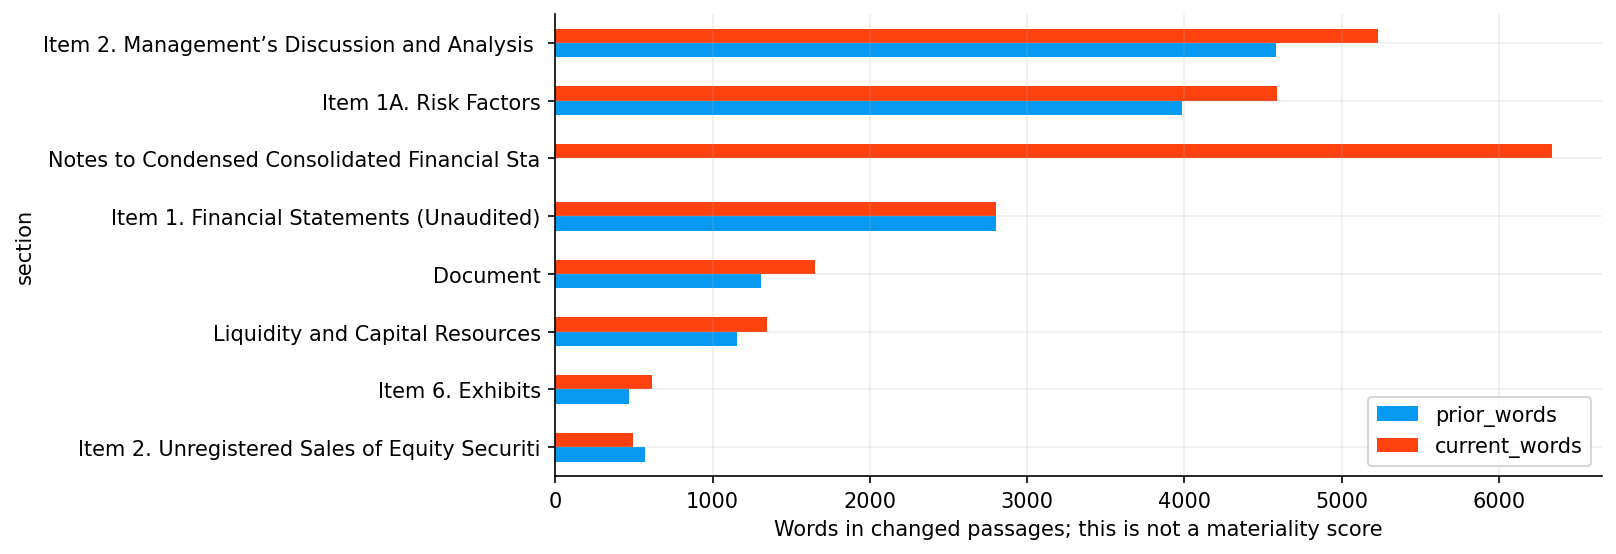

In [28]:
company_question = f"Which changes in {ticker}'s latest filing and financial results are material, including tensions between earnings and cash generation?"
changes = compare_sections(previous_doc, current_doc)
change_table = pd.DataFrame([{"section": row["section"], "kind": row["kind"],
                             "prior_words": len(row.get("before", "").split()),
                             "current_words": len(row.get("after", "").split()),
                             "before": row.get("before", "")[:300], "after": row.get("after", "")[:300]}
                            for row in changes])
display(change_table.head(8))
changed_words = change_table.groupby("section")[["prior_words", "current_words"]].sum()
changed_words = changed_words.loc[changed_words.sum(axis=1).nlargest(8).index]
changed_words.iloc[::-1].plot.barh(figsize=(9, 4))
plt.yticks(range(len(changed_words)), [section[:45] for section in changed_words.iloc[::-1].index])
plt.xlabel("Words in changed passages; this is not a materiality score")
plt.show()
compensation = compensation_change(previous_doc, current_doc)
if compensation is not None:
    display(pd.Series(compensation))
change_rows, selected_changes = select_change_evidence(previous_doc, current_doc, changes, ticker=ticker, count=runtime.count, question=company_question)

In [29]:
company_plan = resolve_plan(config, runtime, company_question, as_of=cutoff, ticker=ticker)
company_packet, company_budget = prepare_packet(config, runtime, store, index, registry, company_question,
    as_of=cutoff, task="sec_change", ticker=ticker, plan=company_plan, evidence=change_rows,
    contexts=["fundamentals", "risk", "factors", "market", "credit"])
display(pd.DataFrame(company_packet["evidence"])[["source", "title", "available_at"]])
print(company_question)
company_answer = analyze_packet(config, runtime, company_question, company_packet, task="sec_change")
display(company_answer)

,source,title,available_at
0,structured_context,Fundamentals · calculated Quantfinlab context,2026-08-26T20:36:00+00:00
1,structured_context,Risk · calculated Quantfinlab context,2026-09-11T22:00:00+00:00
2,structured_context,Market · calculated Quantfinlab context,2026-09-11T22:00:00+00:00
3,structured_context,Credit · calculated Quantfinlab context,2026-08-29T12:31:29.007767+00:00
4,sec,NVIDIA CORP 10-Q 2025-07-27 00:00:00 · Item 1. Financial Statements (Unaudited) · before,2025-08-27T20:52:07+00:00
5,sec,NVIDIA CORP 10-Q 2026-07-26 00:00:00 · Item 1. Financial Statements (Unaudited) · after,2026-08-26T20:36:00+00:00
6,sec,NVIDIA CORP EX-99.1 2026-08-26 00:00:00,2026-08-26T20:21:19+00:00


22:44:47 | Reused saved sec_change analysis


Which changes in NVDA's latest filing and financial results are material, including tensions between earnings and cash generation?


AnalysisReport(question="Which changes in NVDA's latest filing and financial results are material, including tensions between earnings and cash generation?", task='sec_change', as_of='2026-09-14T16:57:55+00:00', analysis=AnalysisTarget(conclusion='Operating cash flow fell 52.18 percent from the prior quarter while net income rose 2.34 percent. Cash generation and earnings must move together before a profitable expansion is established.', materiality='high', claims=[Claim(statement='The filing states: Operating cash flow fell 52.18 percent from the prior quarter while net income rose 2.34 percent.', evidence_ids=['context-fundamentals-554c2b7c75527632'], kind='fact'), Claim(statement='Cash generation and earnings must move together before a profitable expansion is established.', evidence_ids=['context-fundamentals-554c2b7c75527632'], kind='interpretation')], what_changed='Operating cash flow fell 52.18 percent from the prior quarter while net income rose 2.34 percent. Cash generation and earnings must move together before a profitable expansion is established.', why_it_matters='Cash generation and earnings must move together before a profitable expansion is established.', uncertainty=['A cash generation rate or a normalized operating cash flow estimate would clarify how much of the operating cash flow change is persistent.', 'The selected excerpts do not establish the sole driver of any asset-price move.']), packet={'as_of': '2026-09-14T16:57:55+00:00', 'task': 'sec_change', 'entities': ['NVDA'], 'evidence': [{'evidence_id': 'context-fundamentals-554c2b7c75527632', 'document_id': 'context-fundamentals-554c2b7c75527632', 'available_at': '2026-08-26T20:36:00+00:00', 'source': 'structured_context', 'title': 'Fundamentals · calculated Quantfinlab context', 'tickers': ['NVDA'], 'entities': [], 'text': 'NVDA financial results through 2026-07-26. Operating cash flow was 0.70 times net income over the trailing 12 months, so cash generation was below reported earnings. In the latest quarter, operating cash flow fell 52.18 percent from the prior quarter while net income rose 2.34 percent. trailing 12-month operating margin 65.21 percent. trailing 12-month net margin 63.66 percent. trailing 12-month free cash flow margin 41.92 percent. fundamentals; observation 2026-08-21 00:00:00+00:00; current. entity: NVIDIA CORP ticker: NVDA metrics.gross margin ttm: 74.67 percent metrics.operating margin ttm: 65.21 percent metrics.net margin ttm: 63.66 percent metrics.fcf margin ttm: 41.92 percent metrics.cfo net income: 0.70 metrics.debt assets: 10.42 percent metrics.current ratio: 4.59 metrics.interest coverage: 426.74 metrics.capex revenue: 2.43 percent metrics.roa: 66.54 percent metrics.roe: 90.88 percent metrics.accruals assets: 20.19 percent metrics.asset turnover: 1.05 metrics.cfo debt: 4.03 metrics.net debt assets: 3.41 percent metrics.cash ratio: 0.52 metrics.working capital revenue: 0.51 metrics.dividend payout: 3.51 percent growth.capex qoq: 52.36 percent growth.cfo qoq: -52.18 percent growth.net income qoq: 2.34 percent growth.operating expenses qoq: 10.33 percent growth.operating income qoq: 19.05 percent growth.revenue qoq: 17.90 percent growth.net income q yoy: 125.90 percent growth.operating expenses q yoy: 55.33 percent growth.operating income q yoy: 124.10 percent growth.revenue q yoy: 105.85 percent margin trends.operating margin.quarters.2025-07-27: 60.84 percent margin trends.operating margin.quarters.2025-10-26: 63.17 percent margin trends.operating margin.quarters.2026-01-25: 65.02 percent margin trends.operating margin.quarters.2026-04-26: 65.60 percent margin trends.operating margin.quarters.2026-07-26: 66.24 percent margin trends.operating margin.changes.quarter change pp: 0.64 percentage points margin trends.operating margin.changes.year change pp: 5.39 percentage points margin trends.gross margin.quarters.2025-07-27: 72.42 percent margin trends.gross margin.quarters.2025-10-26: 73.41 percent margin trends.gross margin.quar

published_at                                                                              2026-08-12T12:30:00+00:00
before_date                                                                                              2026-08-11
after_date                                                                                               2026-08-12
available_at                                                                              2026-08-12T22:00:00+00:00
scope           Daily close-to-close window using regular US session times; other news overlaps this window. The...
dtype: str

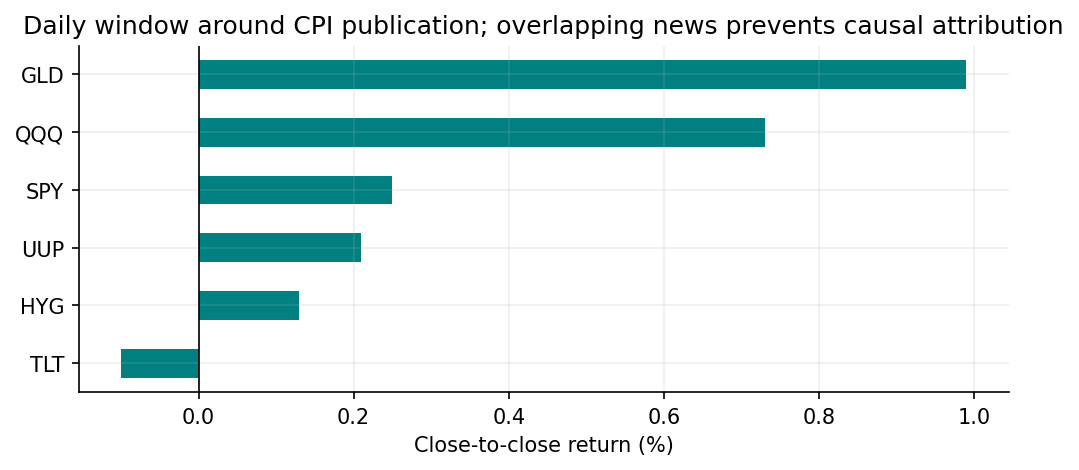

,release,title,available_at,report_period,url
0,current,Consumer Price Index News Release,2026-08-12 12:30:00+00:00,None,https://www.bls.gov/news.release/archives/cpi_08122026.htm
1,previous,Consumer Price Index News Release,2026-07-14 12:30:00+00:00,None,https://www.bls.gov/news.release/archives/cpi_07142026.htm


,value,period,available_at,unit,change,payroll_change_persons
CPIAUCSL,332.813,2026-07-01,2026-08-13T03:59:59+00:00,index,"{'previous_value': 332.568, 'change': 0.245, 'change_percent': 0.073669, 'year_change_percent': ...",NaN
FEDFUNDS,3.63,2026-07-01,2026-08-04T03:59:59+00:00,percent,"{'previous_value': 3.63, 'change': 0.0}",NaN
PAYEMS,158858.0,2026-07-01,2026-08-08T03:59:59+00:00,thousands of persons,"{'previous_value': 158881.0, 'change': -23.0, 'change_percent': -0.014476, 'year_change_percent'...",-23000
PCEPILFE,130.658,2026-07-01,2026-08-27T03:59:59+00:00,index,"{'previous_value': 130.338, 'change': 0.32, 'change_percent': 0.245516, 'year_change_percent': 3...",NaN
UNRATE,4.1,2026-07-01,2026-08-08T03:59:59+00:00,percent,"{'previous_value': 4.2, 'change': -0.1}",NaN


In [30]:
current_release, previous_release = select_macro_release(store, "cpi", as_of=cutoff)
macro_rows = release_evidence(current_release, previous_release, family="cpi")
reaction = release_reaction(prices, published_at=current_release.published_at, as_of=cutoff)
macro_rows += reaction_evidence(reaction, current_release)
if reaction is not None:
    display(pd.Series({key: value for key, value in reaction.items() if key != "returns_percent"}))
    pd.Series(reaction["returns_percent"]).sort_values().plot.barh(figsize=(8, 3), color=palette[3])
    plt.axvline(0, color="black", linewidth=0.8)
    plt.xlabel("Close-to-close return (%)")
    plt.title("Daily window around CPI publication; overlapping news prevents causal attribution")
    plt.show()
display(pd.DataFrame([{"release": label, "title": document.title, "available_at": document.available_at,
                      "report_period": document.report_period, "url": document.source_url}
                     for label, document in [("current", current_release), ("previous", previous_release)] if document is not None]))
display(pd.DataFrame(snapshots["macro"].measures).T)

In [31]:
macro_question = "What changed in the latest CPI release, and which details matter for the inflation trend and policy interpretation?"
macro_plan = resolve_plan(config, runtime, macro_question, as_of=cutoff)
macro_packet, macro_budget = prepare_packet(config, runtime, store, index, registry, macro_question,
    as_of=cutoff, task="macro", plan=macro_plan, evidence=macro_rows,
    contexts=["macro", "rates", "financial_conditions", "market"])
print(macro_question)
macro_answer = analyze_packet(config, runtime, macro_question, macro_packet, task="macro")
display(macro_answer)

22:44:49 | Reused saved macro analysis


What changed in the latest CPI release, and which details matter for the inflation trend and policy interpretation?


AnalysisReport(question='What changed in the latest CPI release, and which details matter for the inflation trend and policy interpretation?', task='macro', as_of='2026-09-14T16:57:55+00:00', analysis=AnalysisTarget(conclusion='The consumer-price headline increased, while the underlying component mix and the policy outlook remain mixed.', materiality='high', claims=[Claim(statement='The release reports a consumer-price increase: The Consumer Price Index for All Urban Consumers (CPI-U) increased 0.1 percent on a seasonally adjusted basis in July.', evidence_ids=['bls-a4d76dd457c23788e5ff9e36:release:0:25425d5057'], kind='fact'), Claim(statement='The release reports a consumer-price increase: The index for all items less food and energy rose 0.2 percent after being unchanged in June.', evidence_ids=['bls-a4d76dd457c23788e5ff9e36:release:1:496ea2118d'], kind='fact'), Claim(statement='The release reports a consumer-price increase: The index for shelter rose 0.1 percent in July, accounting for roughly two-thirds of the monthly all items increase.', evidence_ids=['bls-a4d76dd457c23788e5ff9e36:release:2:dd65926c28'], kind='fact'), Claim(statement='The component mix and policy outlook remain mixed, so a single headline cannot establish a persistent trend.', evidence_ids=['bls-a4d76dd457c23788e5ff9e36:release:0:25425d5057', 'bls-a4d76dd457c23788e5ff9e36:release:1:496ea2118d', 'bls-a4d76dd457c23788e5ff9e36:release:2:dd65926c28'], kind='interpretation')], what_changed='The consumer-price headline increased, while the underlying component mix and the policy outlook remain mixed.', why_it_matters='The component mix and policy outlook remain mixed, so a single headline cannot establish a persistent trend.', uncertainty=['A release window cannot establish a causal market reaction; return timing and other daily factors matter.', 'The selected excerpts do not establish the sole driver of any asset-price move.']), packet={'as_of': '2026-09-14T16:57:55+00:00', 'task': 'macro', 'entities': [], 'evidence': [{'evidence_id': 'bls-a4d76dd457c23788e5ff9e36:release:0:25425d5057', 'document_id': 'bls-a4d76dd457c23788e5ff9e36', 'available_at': '2026-08-12T12:30:00+00:00', 'source': 'bls', 'title': 'Consumer Price Index News Release', 'tickers': [], 'entities': [], 'text': 'The Consumer Price Index for All Urban Consumers (CPI-U) increased 0.1 percent on a seasonally adjusted basis in July \nafter falling 0.4 percent in June, the U.S. Bureau of Labor Statistics reported today. Over the last 12 months, the \nall items index increased 3.4 percent before seasonal adjustment.', 'text_hash': '25425d5057f0e930d1932eb47a8bb968ec9f409e77379b72dd5954568a3e09f6', 'source_url': 'https://www.bls.gov/news.release/archives/cpi_08122026.htm'}, {'evidence_id': 'bls-a4d76dd457c23788e5ff9e36:release:1:496ea2118d', 'document_id': 'bls-a4d76dd457c23788e5ff9e36', 'available_at': '2026-08-12T12:30:00+00:00', 'source': 'bls', 'title': 'Consumer Price Index News Release', 'tickers': [], 'entities': [], 'text': 'The index for all items less food and energy rose 0.2 percent after being unchanged in June. Indexes that increased \nover the month include medical care, airline fares, communication, education, and recreation. Conversely, the index for \nmotor vehicle insurance was among the major indexes that decreased in July.', 'text_hash': '496ea2118dc21a8793ee81067d0083672083d84288f5d248f4da15d35a3da0bd', 'source_url': 'https://www.bls.gov/news.release/archives/cpi_08122026.htm'}, {'evidence_id': 'bls-a4d76dd457c23788e5ff9e36:release:2:dd65926c28', 'document_id': 'bls-a4d76dd457c23788e5ff9e36', 'available_at': '2026-08-12T12:30:00+00:00', 'source': 'bls', 'title': 'Consumer Price Index News Release', 'tickers': [], 'entities': [], 'text': 'The index for shelter rose 0.1 percent in July, accounting for roughly two-thirds of the monthly all items increase. The \nindex for food also increased 0.1 percent over the month, as the index for food away from home increased 0.3 percent. In \n

In [32]:
market_question = "Do equity breadth, credit, Treasury duration and gold support the same market interpretation? Identify the strongest disagreement."
market_plan = resolve_plan(config, runtime, market_question, as_of=cutoff)
market_packet, market_budget = prepare_packet(config, runtime, store, index, registry, market_question,
    as_of=cutoff, task="market", plan=market_plan,
    contexts=["market", "risk", "cross_asset", "rates", "volatility", "financial_conditions", "credit", "factors", "macro"])
print(market_question)
market_answer = analyze_packet(config, runtime, market_question, market_packet, task="market")
display(market_answer)

22:44:49 | Reused saved market analysis


Do equity breadth, credit, Treasury duration and gold support the same market interpretation? Identify the strongest disagreement.


AnalysisReport(question='Do equity breadth, credit, Treasury duration and gold support the same market interpretation? Identify the strongest disagreement.', task='market', as_of='2026-09-14T16:57:55+00:00', analysis=AnalysisTarget(conclusion='The generated interpretation did not pass all checks; traceable excerpts are retained below.', materiality='uncertain', claims=[Claim(statement='The source reports: Market close snapshot for 2026-09-11; returns over 1 trading day: SPY +0.85 percent; QQQ +0.87 percent; IWM +0.41 percent; HYG -0.03 percent; LQD -0.04 percent; IEF -0.19 percent; TLT +0.11 percent; GLD +0.61 percent; DBC -1.37 percent; UUP +0.14 percent.', evidence_ids=['context-market-a300818a59e5f3ec'], kind='fact'), Claim(statement='The source reports: Across the selected ETF universe, 10.00 percent had positive returns over 21 trading days.', evidence_ids=['context-cross_asset-167c7eb1ac3d4992'], kind='fact')], what_changed='The retained claims are listed below.', why_it_matters='The complete generated interpretation did not pass validation.', uncertainty=['Unsupported portions were removed; review the original evidence before drawing a conclusion.']), packet={'as_of': '2026-09-14T16:57:55+00:00', 'task': 'market', 'entities': [], 'evidence': [{'evidence_id': 'context-market-a300818a59e5f3ec', 'document_id': 'context-market-a300818a59e5f3ec', 'available_at': '2026-09-11T22:00:00+00:00', 'source': 'structured_context', 'title': 'Market · calculated Quantfinlab context', 'tickers': [], 'entities': [], 'text': 'Market close snapshot for 2026-09-11; returns over 1 trading day: SPY +0.85 percent; QQQ +0.87 percent; IWM +0.41 percent; HYG -0.03 percent; LQD -0.04 percent; IEF -0.19 percent; TLT +0.11 percent; GLD +0.61 percent; DBC -1.37 percent; UUP +0.14 percent. market; observation 2026-09-11 22:00:00+00:00; current. SPY.close: 764.29 SPY return over 1 trading days: 0.85 percent SPY return over 5 trading days: -1.15 percent SPY return over 21 trading days: -1.06 percent SPY return over 63 trading days: 3.86 percent SPY.move z: 0.97 SPY.data at: 2026-09-11T22:00:00+00:00 QQQ.close: 714.88 QQQ return over 1 trading days: 0.87 percent QQQ return over 5 trading days: -0.39 percent QQQ return over 21 trading days: -1.22 percent QQQ return over 63 trading days: -0.20 percent QQQ.move z: 0.64 QQQ.data at: 2026-09-11T22:00:00+00:00 IWM.close: 288.89 IWM return over 1 trading days: 0.41 percent IWM return over 5 trading days: -2.13 percent IWM return over 21 trading days: -4.57 percent IWM return over 63 trading days: -0.29 percent IWM.move z: 0.27 IWM.data at: 2026-09-11T22:00:00+00:00 HYG.close: 78.60 HYG return over 1 trading days: -0.03 percent HYG return over 5 trading days: -0.77 percent HYG return over 21 trading days: -1.27 percent HYG return over 63 trading days: -1.22 percent HYG.move z: -0.14 HYG.data at: 2026-09-11T22:00:00+00:00 LQD.close: 104.32 LQD return over 1 trading days: -0.04 percent LQD return over 5 trading days: -1.12 percent LQD return over 21 trading days: -1.70 percent LQD return over 63 trading days: -4.03 percent LQD.move z: -0.08 LQD.data at: 2026-09-11T22:00:00+00:00 IEF.close: 91.01 IEF return over 1 trading days: -0.19 percent IEF return over 5 trading days: -1.38 percent IEF return over 21 trading days: -2.10 percent IEF return over 63 trading days: -3.21 percent IEF.move z: -0.60 IEF.data at: 2026-09-11T22:00:00+00:00 TLT.close: 80.87 TLT return over 1 trading days: 0.11 percent TLT return over 5 trading days: -1.46 percent TLT return over 21 trading days: -1.51 percent TLT return over 63 trading', 'text_hash': 'a300818a59e5f3ecf460d4fc1cfecf31e8643c59a3c401e6b7f5b165e529c561', 'source_url': ''}, {'evidence_id': 'context-risk-1e9f379c23e0ae1c', 'document_id': 'context-risk-1e9f379c23e0ae1c', 'available_at': '2026-09-11T22:00:00+00:00', 'source': 'structured_context', 'title': 'Risk · calculated Quantfinlab context', 'tickers': [], 'entities': [], 'text': 'risk; observation 2026-09-11 22:00:00+00:00

,task,checks_passed,cached,evidence_items,attempts,seconds,errors
0,event,True,True,7,1,34.000,
1,sec_change,True,True,7,1,38.844,
2,macro,True,True,12,1,54.984,
3,market,False,True,8,2,113.610,Fact claim is not a traceable excerpt of its cited evidence: The source reports: The broad dolla...


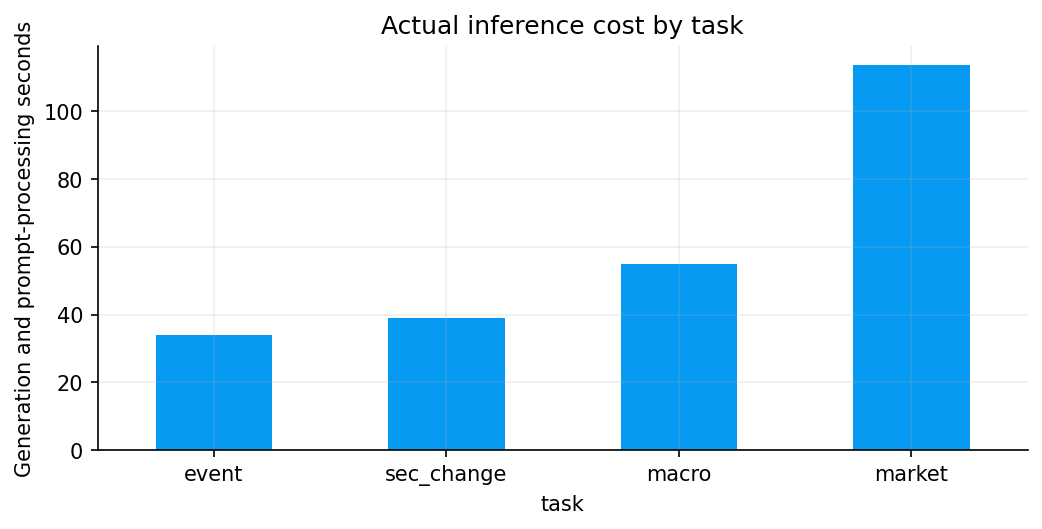

Validated structure and traceable numbers do not guarantee correct financial interpretation.


In [33]:
reports = [event_report, company_answer, macro_answer, market_answer]
audit = pd.DataFrame([{"task": report.task, "checks_passed": report.validated, "cached": report.cached,
                       "evidence_items": len(report.packet["evidence"]), "attempts": len(report.attempts),
                       "seconds": sum(attempt["seconds"] for attempt in report.attempts),
                       "errors": "; ".join(report.errors)} for report in reports])
display(audit)
audit.set_index("task").seconds.plot.bar(color=palette[0], rot=0)
plt.ylabel("Generation and prompt-processing seconds")
plt.title("Actual inference cost by task")
plt.show()
for report in reports:
    report.save(config.workspace / "outputs" / f"{report.task}-{report.cache_key[:12]}.html")
print("Validated structure and traceable numbers do not guarantee correct financial interpretation.")

In [34]:
from quantfinlab.analyst import FinancialAnalyst

analyst = FinancialAnalyst.from_repo(root, runtime=runtime, as_of=cutoff, identity=identity)
started = perf_counter()
reused_company = analyst.company(ticker, company_question)
display(pd.Series({"same_response_identity": reused_company.cache_key == company_answer.cache_key,
                   "answer_reused": reused_company.cached, "elapsed_seconds": perf_counter() - started}))
assert reused_company.cache_key == company_answer.cache_key and reused_company.cached
print("The analyst calls the same selection, retrieval, context, generation and validation functions shown above.")

22:45:07 | Packed 7 evidence items, 6566 prompt tokens


22:45:07 | Reused saved sec_change analysis


same_response_identity         True
answer_reused                  True
elapsed_seconds           18.001865
dtype: object

The analyst calls the same selection, retrieval, context, generation and validation functions shown above.


In [35]:
cash_question = f"Does {ticker}'s cash generation support its reported profitability, and what specific evidence limits that conclusion?"
print(cash_question)
cash_answer = analyst.ask(cash_question, ticker=ticker)
display(cash_answer)

22:45:08 | Packed 8 evidence items, 6697 prompt tokens


22:45:08 | Reused saved question analysis


Does NVDA's cash generation support its reported profitability, and what specific evidence limits that conclusion?


AnalysisReport(question="Does NVDA's cash generation support its reported profitability, and what specific evidence limits that conclusion?", task='question', as_of='2026-09-14T16:57:55+00:00', analysis=AnalysisTarget(conclusion='Operating cash flow fell while net income rose, so cash generation cannot be taken as a positive profit signal.', materiality='high', claims=[Claim(statement='The source reports: Operating cash flow was 0.70 times net income over the trailing 12 months, so cash generation was below reported earnings.', evidence_ids=['context-fundamentals-554c2b7c75527632'], kind='fact'), Claim(statement='The source reports: Operating cash flow fell while net income rose, so cash generation cannot be taken as a positive profit signal.', evidence_ids=['context-fundamentals-554c2b7c75527632'], kind='interpretation'), Claim(statement='The selected financial statement must not be confused with a cash-generating-good sign. The passage alone does not establish a positive cash-flow-from-investments reading.', evidence_ids=['context-fundamentals-554c2b7c75527632'], kind='uncertainty')], what_changed='Operating cash flow fell while net income rose, so cash generation cannot be taken as a positive profit signal.', why_it_matters='The selected financial statement must not be confused with a cash-generating-good sign. The passage alone does not establish a positive cash-flow-from-investments reading.', uncertainty=['The passage does not quantify every cash outflow, and operating cash flow is not a measure of recurring earnings.', 'The comparison is limited to the cited excerpts and does not establish a causal market reaction.']), packet={'as_of': '2026-09-14T16:57:55+00:00', 'task': 'market', 'entities': ['NVDA'], 'evidence': [{'evidence_id': 'context-fundamentals-554c2b7c75527632', 'document_id': 'context-fundamentals-554c2b7c75527632', 'available_at': '2026-08-26T20:36:00+00:00', 'source': 'structured_context', 'title': 'Fundamentals · calculated Quantfinlab context', 'tickers': ['NVDA'], 'entities': [], 'text': 'NVDA financial results through 2026-07-26. Operating cash flow was 0.70 times net income over the trailing 12 months, so cash generation was below reported earnings. In the latest quarter, operating cash flow fell 52.18 percent from the prior quarter while net income rose 2.34 percent. trailing 12-month operating margin 65.21 percent. trailing 12-month net margin 63.66 percent. trailing 12-month free cash flow margin 41.92 percent. fundamentals; observation 2026-08-21 00:00:00+00:00; current. entity: NVIDIA CORP ticker: NVDA metrics.gross margin ttm: 74.67 percent metrics.operating margin ttm: 65.21 percent metrics.net margin ttm: 63.66 percent metrics.fcf margin ttm: 41.92 percent metrics.cfo net income: 0.70 metrics.debt assets: 10.42 percent metrics.current ratio: 4.59 metrics.interest coverage: 426.74 metrics.capex revenue: 2.43 percent metrics.roa: 66.54 percent metrics.roe: 90.88 percent metrics.accruals assets: 20.19 percent metrics.asset turnover: 1.05 metrics.cfo debt: 4.03 metrics.net debt assets: 3.41 percent metrics.cash ratio: 0.52 metrics.working capital revenue: 0.51 metrics.dividend payout: 3.51 percent growth.capex qoq: 52.36 percent growth.cfo qoq: -52.18 percent growth.net income qoq: 2.34 percent growth.operating expenses qoq: 10.33 percent growth.operating income qoq: 19.05 percent growth.revenue qoq: 17.90 percent growth.net income q yoy: 125.90 percent growth.operating expenses q yoy: 55.33 percent growth.operating income q yoy: 124.10 percent growth.revenue q yoy: 105.85 percent margin trends.operating margin.quarters.2025-07-27: 60.84 percent margin trends.operating margin.quarters.2025-10-26: 63.17 percent margin trends.operating margin.quarters.2026-01-25: 65.02 percent margin trends.operating margin.quarters.2026-04-26: 65.60 percent margin trends.operating margin.quarters.2026-07-26: 66.24 percent margin trends.operating margin.changes.quarter change pp: 0.64 percentage points margin trends.

In [36]:
event_board = analyst.events(days=7, limit=3)
display(pd.DataFrame([{"family": event.family, "importance": event.importance, "available_at": event.available_at,
                      "summary": event.what_happened} for event in event_board]))
print("The daily brief receives compact event analyses and market context, with their source dates retained.")

22:45:09 | Packed 7 evidence items, 3344 prompt tokens


22:45:09 | Reused saved event analysis


22:45:09 | Packed 3 evidence items, 1287 prompt tokens


22:45:09 | Reused saved event analysis


22:45:10 | Packed 4 evidence items, 1858 prompt tokens


22:45:10 | Reused saved event analysis


,family,importance,available_at,summary
0,energy,high,2026-09-12 20:25:04.728959+00:00,"For the week ending September 04, 2026, U.S. refineries processed 17.6 million barrels per day (..."
1,positioning,medium,2026-09-12 20:25:05.398215+00:00,The position counts and their signs determine whether the market reading is directional or ambig...
2,inflation,medium,2026-09-10 12:30:00+00:00,"The Producer Price Index for final demand moved up 0.4 percent in August, seasonally adjusted, t..."


The daily brief receives compact event analyses and market context, with their source dates retained.


In [37]:
print("Which market moves and recent events matter, and which interpretations remain uncertain?")
daily_analysis = analyst.daily_brief(days=7, limit=3)
display(daily_analysis)
daily_analysis.report.save(config.workspace / "outputs" / f"daily-{daily_analysis.report.cache_key[:12]}.html")

Which market moves and recent events matter, and which interpretations remain uncertain?


22:45:11 | Packed 7 evidence items, 3344 prompt tokens


22:45:11 | Reused saved event analysis


22:45:11 | Packed 3 evidence items, 1287 prompt tokens


22:45:11 | Reused saved event analysis


...

22:45:13 | Inference 0s; prompt {'total': 6606, 'cache': 0, 'processed': 0, 'time_ms': 0}; generated text 0 chars


22:45:29 | Inference 15s; prompt {'total': 6606, 'cache': 0, 'processed': 4608, 'time_ms': 15210}; generated text 0 chars


22:45:44 | Inference 30s; prompt 6606; generated text 483 chars


DailyBrief(report=AnalysisReport(question='Which market moves and recent events matter in this daily brief, and which interpretations remain uncertain? Compare equities, credit and the supplied event facts. Keep the observation dates distinct.', task='daily', as_of='2026-09-14T16:57:55+00:00', analysis=AnalysisTarget(conclusion='Equities rose while high-yield bonds fell, with the credit gap widening; the event passage concerns refinery capacity rather than a broad market shock.', materiality='medium', claims=[Claim(statement='SPY rose, with a return of 0.85 percent over the selected trading days.', evidence_ids=['context-market-a300818a59e5f3ec'], kind='fact'), Claim(statement='QQQ rose, with a return of 0.87 percent over the selected trading days.', evidence_ids=['context-market-a300818a59e5f3ec'], kind='fact'), Claim(statement='HYG returned -0.03 percent and LQD returned -0.04 percent, while TLT returned 0.11 percent.', evidence_ids=['context-market-a300818a59e5f3ec'], kind='fact'), Claim(statement='The passage concerns refinery capacity rather than a broad market shock. The selected ETF universe is not a market-wide measure.', evidence_ids=['context-cross_asset-167c7eb1ac3d4992', 'context-rates-b9f58d20ac198e9d'], kind='interpretation')], what_changed='Equities rose while high-yield bonds fell, with the credit gap widening; the event passage concerns refinery capacity rather than a broad market shock. The selected ETF universe is not a market-wide measure.', why_it_matters='The passage concerns refinery capacity rather than a broad market shock. The selected ETF universe is not a market-wide measure.', uncertainty=['Returns co-move, and a single release cannot establish a causal market reaction.', 'The selected ETF universe is not a market-wide measure.']), packet={'as_of': '2026-09-14T16:57:55+00:00', 'task': 'daily', 'entities': [], 'evidence': [{'evidence_id': 'context-market-a300818a59e5f3ec', 'document_id': 'context-market-a300818a59e5f3ec', 'available_at': '2026-09-11T22:00:00+00:00', 'source': 'structured_context', 'title': 'Market · calculated Quantfinlab context', 'tickers': [], 'entities': [], 'text': 'Market close snapshot for 2026-09-11; returns over 1 trading day: SPY +0.85 percent; QQQ +0.87 percent; IWM +0.41 percent; HYG -0.03 percent; LQD -0.04 percent; IEF -0.19 percent; TLT +0.11 percent; GLD +0.61 percent; DBC -1.37 percent; UUP +0.14 percent. market; observation 2026-09-11 22:00:00+00:00; current. SPY.close: 764.29 SPY return over 1 trading days: 0.85 percent SPY return over 5 trading days: -1.15 percent SPY return over 21 trading days: -1.06 percent SPY return over 63 trading days: 3.86 percent SPY.move z: 0.97 SPY.data at: 2026-09-11T22:00:00+00:00 QQQ.close: 714.88 QQQ return over 1 trading days: 0.87 percent QQQ return over 5 trading days: -0.39 percent QQQ return over 21 trading days: -1.22 percent QQQ return over 63 trading days: -0.20 percent QQQ.move z: 0.64 QQQ.data at: 2026-09-11T22:00:00+00:00 IWM.close: 288.89 IWM return over 1 trading days: 0.41 percent IWM return over 5 trading days: -2.13 percent IWM return over 21 trading days: -4.57 percent IWM return over 63 trading days: -0.29 percent IWM.move z: 0.27 IWM.data at: 2026-09-11T22:00:00+00:00 HYG.close: 78.60 HYG return over 1 trading days: -0.03 percent HYG return over 5 trading days: -0.77 percent HYG return over 21 trading days: -1.27 percent HYG return over 63 trading days: -1.22 percent HYG.move z: -0.14 HYG.data at: 2026-09-11T22:00:00+00:00 LQD.close: 104.32 LQD return over 1 trading days: -0.04 percent LQD return over 5 trading days: -1.12 percent LQD return over 21 trading days: -1.70 percent LQD return over 63 trading days: -4.03 percent LQD.move z: -0.08 LQD.data at: 2026-09-11T22:00:00+00:00 IEF.close: 91.01 IEF return over 1 trading days: -0.19 percent IEF return over 5 trading days: -1.38 percent IEF return over 21 trading days: -2.10 percent IEF return over 63 trading days: -3.21 percent IEF.move z: -0.60 IEF.data at: 2026

WindowsPath('E:/daneshgah/quantitative-finance-lab/workspace/financial_analyst/outputs/daily-9a5a84b4c309.html')

In [38]:
final_question = "Which signals in the current market snapshot conflict with a simple risk-on or risk-off interpretation, and which evidence matters most?"
print(final_question)
final_answer = analyst.ask(final_question)
display(final_answer)
analyst.close()
index.close()
event_store.close()
print("The server is stopped. The model, calibration, documents, snapshots and answers remain cached.")

Which signals in the current market snapshot conflict with a simple risk-on or risk-off interpretation, and which evidence matters most?


22:46:00 | Packed 9 evidence items, 6665 prompt tokens


22:46:00 | Reused saved question analysis


AnalysisReport(question='Which signals in the current market snapshot conflict with a simple risk-on or risk-off interpretation, and which evidence matters most?', task='question', as_of='2026-09-14T16:57:55+00:00', analysis=AnalysisTarget(conclusion='Equities moved in the same direction, while bond duration and the dollar showed opposite moves.', materiality='medium', claims=[Claim(statement='SPY rose, with a return over the trading days of 0.85 percent; QQQ returned 0.87 percent.', evidence_ids=['context-market-a300818a59e5f3ec'], kind='fact'), Claim(statement='HYG returned -0.03 percent and LQD returned -0.04 percent, while TLT returned 0.11 percent and GLD returned 0.61 percent.', evidence_ids=['context-market-a300818a59e5f3ec'], kind='fact'), Claim(statement='The bond gap and the dollar move should not be read as a risk-free rate-driven equity response. The bond duration and dollar moves should not be read as a risk-free rate-driven response.', evidence_ids=['context-market-a300818a59e5f3ec', 'context-cross_asset-167c7eb1ac3d4992', 'context-risk-1e9f379c23e0ae1c'], kind='interpretation')], what_changed='Equities moved in the same direction, while bond duration and the dollar showed opposite moves.', why_it_matters='The bond gap and the dollar move should not be read as a risk-free rate-driven equity response. The bond duration and dollar moves should not be read as a risk-free rate-driven response.', uncertainty=['The market snapshot cannot establish a causal market reaction to an event outside the selected universe.', 'The comparison is limited to the cited excerpts and does not establish the sole driver of any move.']), packet={'as_of': '2026-09-14T16:57:55+00:00', 'task': 'market', 'entities': [], 'evidence': [{'evidence_id': 'context-market-a300818a59e5f3ec', 'document_id': 'context-market-a300818a59e5f3ec', 'available_at': '2026-09-11T22:00:00+00:00', 'source': 'structured_context', 'title': 'Market · calculated Quantfinlab context', 'tickers': [], 'entities': [], 'text': 'Market close snapshot for 2026-09-11; returns over 1 trading day: SPY +0.85 percent; QQQ +0.87 percent; IWM +0.41 percent; HYG -0.03 percent; LQD -0.04 percent; IEF -0.19 percent; TLT +0.11 percent; GLD +0.61 percent; DBC -1.37 percent; UUP +0.14 percent. market; observation 2026-09-11 22:00:00+00:00; current. SPY.close: 764.29 SPY return over 1 trading days: 0.85 percent SPY return over 5 trading days: -1.15 percent SPY return over 21 trading days: -1.06 percent SPY return over 63 trading days: 3.86 percent SPY.move z: 0.97 SPY.data at: 2026-09-11T22:00:00+00:00 QQQ.close: 714.88 QQQ return over 1 trading days: 0.87 percent QQQ return over 5 trading days: -0.39 percent QQQ return over 21 trading days: -1.22 percent QQQ return over 63 trading days: -0.20 percent QQQ.move z: 0.64 QQQ.data at: 2026-09-11T22:00:00+00:00 IWM.close: 288.89 IWM return over 1 trading days: 0.41 percent IWM return over 5 trading days: -2.13 percent IWM return over 21 trading days: -4.57 percent IWM return over 63 trading days: -0.29 percent IWM.move z: 0.27 IWM.data at: 2026-09-11T22:00:00+00:00 HYG.close: 78.60 HYG return over 1 trading days: -0.03 percent HYG return over 5 trading days: -0.77 percent HYG return over 21 trading days: -1.27 percent HYG return over 63 trading days: -1.22 percent HYG.move z: -0.14 HYG.data at: 2026-09-11T22:00:00+00:00 LQD.close: 104.32 LQD return over 1 trading days: -0.04 percent LQD return over 5 trading days: -1.12 percent LQD return over 21 trading days: -1.70 percent LQD return over 63 trading days: -4.03 percent LQD.move z: -0.08 LQD.data at: 2026-09-11T22:00:00+00:00 IEF.close: 91.01 IEF return over 1 trading days: -0.19 percent IEF return over 5 trading days: -1.38 percent IEF return over 21 trading days: -2.10 percent IEF return over 63 trading days: -3.21 percent IEF.move z: -0.60 IEF.data at: 2026-09-11T22:00:00+00:00 TLT.close: 80.87 TLT return over 1 trading days: 0.11 percent TLT return over 5 trading days: -1.46 percent TLT r

The server is stopped. The model, calibration, documents, snapshots and answers remain cached.


In [39]:
answers = [event_report, company_answer, macro_answer, market_answer, cash_answer, daily_analysis.report, final_answer]
answer_review = pd.DataFrame([{"question": report.question, "automatic_checks_passed": report.validated,
                              "retained_claims": len(report.analysis.claims) if report.analysis else 0,
                              "attempts": len(report.attempts), "cached": report.cached,
                              "issues": "; ".join(report.errors)} for report in answers])
display(answer_review)
for report in answers:
    report.save(config.workspace / "outputs" / f"{report.task}-{report.cache_key[:12]}.html")
answer_review.to_csv(config.workspace / "outputs/answer_review.csv", index=False)
print("Fact checks cover source excerpts or matched asset returns, dates, units, citations and repetition. Model interpretations still require judgment.")

,question,automatic_checks_passed,retained_claims,attempts,cached,issues
0,"What happened in this energy event, what changed and why does it matter?",True,2,1,True,
1,"Which changes in NVDA's latest filing and financial results are material, including tensions bet...",True,2,1,True,
2,"What changed in the latest CPI release, and which details matter for the inflation trend and pol...",True,4,1,True,
3,"Do equity breadth, credit, Treasury duration and gold support the same market interpretation? Id...",False,2,2,True,Fact claim is not a traceable excerpt of its cited evidence: The source reports: The broad dolla...
4,"Does NVDA's cash generation support its reported profitability, and what specific evidence limit...",True,3,1,True,
5,"Which market moves and recent events matter in this daily brief, and which interpretations remai...",True,4,1,False,
6,Which signals in the current market snapshot conflict with a simple risk-on or risk-off interpre...,True,3,2,True,


Fact checks cover source excerpts or matched asset returns, dates, units, citations and repetition. Model interpretations still require judgment.
